# 🔍 Entendimiento y Calidad de Datos — Mercado HCH

**Proyecto:** HCH Intelligence Dashboard
**Objetivo de este notebook:** cerrar la etapa **5. Entendimiento de datos** de ASUM-DM antes de seguir construyendo el modelo.


# Plan de Entendimiento y Calidad de Datos — por fuente

Aplicado a cada fuente (F1...F6) de forma individual, antes de pasar a la siguiente.

| Para cada fuente (F1...F6) | Qué revisamos |
|---|---|
| **1.1 Entendimiento por tabla** | Volumen, esquema, muestra de registros, qué representa una fila |
| **1.2 Reglas de negocio** | Las que apliquen a esa tabla (no todas las 4 reglas aplican a todas las fuentes) |
| **1.3 Análisis descriptivo** | Estadísticas, outliers, distribución, cobertura temporal |
| **Entregable 2 — Calidad de datos** | Completitud, unicidad, validez, consistencia, exactitud, oportunidad — para esa tabla específica |

## Fuentes a recorrer, en orden

1. F1. TRM_diaria
2. F2. Commodities_Chicago (maíz, soya)
3. F3. BMC_precios
4. F4. Importaciones_Comtrade
5. F5. Ingredientes_comparacion
6. F6. Sacrificio_bovino



In [2]:
# ── CELDA 0 — Setup global ───────────────────────────────────────
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

DB_PATH = "mercado_hch.db"   # ajusta si tu archivo está en otra carpeta

def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

print(f"✅ Conectado a: {DB_PATH}")
print(f"   Fecha de corrida del notebook: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Conectado a: mercado_hch.db
   Fecha de corrida del notebook: 2026-07-31 09:47


---
# 📦 Entregable 1 — Perfilamiento


## TRM_diario


### 1.1 Entendimiento TRM_diaria

Para cada tabla: volumen, esquema (`PRAGMA table_info`), muestra de registros y qué representa una fila.

In [152]:
import sqlite3, pandas as pd

DB_PATH = "mercado_hch.db"
def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

# Volumen
n = query("SELECT COUNT(*) AS n FROM trm_diaria")['n'].iloc[0]
print(f"📊 trm_diaria: {n:,} filas")

# Esquema
print("\n📋 Esquema:")
print(query("PRAGMA table_info(trm_diaria)").to_string(index=False))

# Muestra
print("\n📄 Muestra (primeras y últimas 5 filas):")
print(query("SELECT * FROM trm_diaria ORDER BY fecha LIMIT 5").to_string(index=False))
print(query("SELECT * FROM trm_diaria ORDER BY fecha DESC LIMIT 5").to_string(index=False))

📊 trm_diaria: 1,668 filas

📋 Esquema:
 cid        name type  notnull dflt_value  pk
   0       fecha TEXT        0       None   0
   1 trm_cop_usd REAL        0       None   0

📄 Muestra (primeras y últimas 5 filas):
     fecha  trm_cop_usd
2022-01-04      4082.75
2022-01-05      4084.11
2022-01-06      4042.36
2022-01-07      4039.31
2022-01-08      4043.46
     fecha  trm_cop_usd
2026-07-29      3205.87
2026-07-28      3205.80
2026-07-27      3210.56
2026-07-26      3210.56
2026-07-25      3210.56


Fila = Un día calendario con la TRM oficial vigente ese día (repetida en fines de semana/festivos por el forward-fill que aplicamos).

### 1.2 Reglas de negocio TRM_diaria

Regla 4 (fechas en rango razonable): que no haya fechas futuras ni anteriores a 2022 (tu filtro de inicio)

In [154]:
# Regla 4 adaptada a TRM: fechas fuera de rango
hoy = pd.Timestamp.today().strftime('%Y-%m-%d')
fechas_invalidas = query(f"""
    SELECT fecha, trm_cop_usd FROM trm_diaria
    WHERE fecha > '{hoy}' OR fecha < '2022-01-01'
""")
print(f"Fechas fuera de rango: {len(fechas_invalidas)}")
if len(fechas_invalidas) > 0:
    print(fechas_invalidas.to_string(index=False))

# Chequeo adicional propio de TRM: valores nulos o negativos/cero
trm_invalida = query("SELECT * FROM trm_diaria WHERE trm_cop_usd IS NULL OR trm_cop_usd <= 0")
print(f"\nValores de TRM nulos o ≤ 0: {len(trm_invalida)}")

Fechas fuera de rango: 0

Valores de TRM nulos o ≤ 0: 0


### 1.3 Análisis descriptivo  TRM_diario

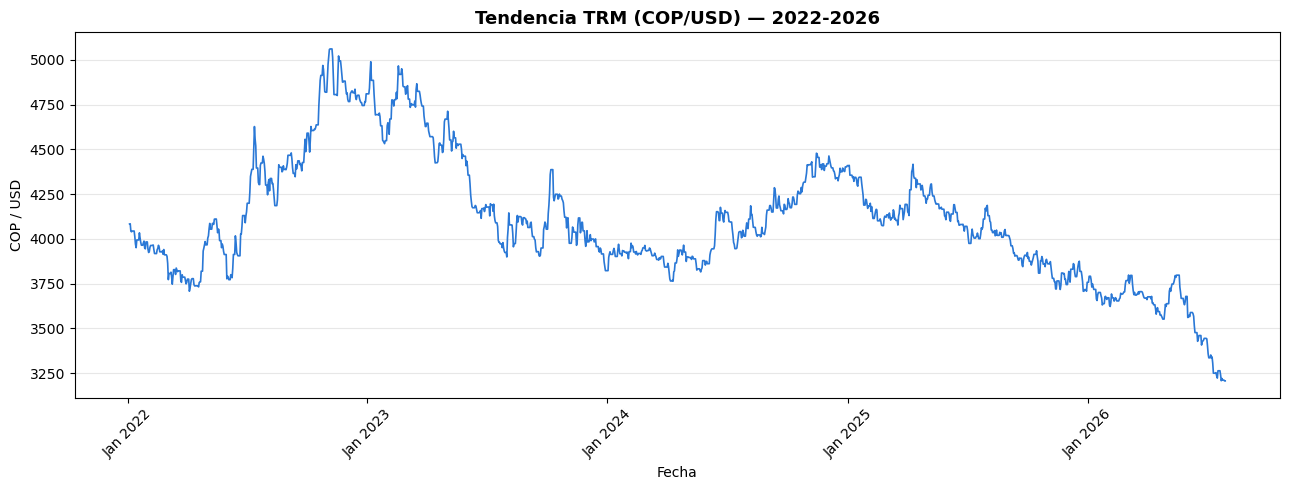

TRM inicial: 4083 | TRM final: 3206
Mínimo: 3206 | Máximo: 5061


In [139]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import sqlite3

DB_PATH = "mercado_hch.db"
with sqlite3.connect(DB_PATH) as con:
    df_trm = pd.read_sql("SELECT fecha, trm_cop_usd FROM trm_diaria ORDER BY fecha", con)

df_trm['fecha'] = pd.to_datetime(df_trm['fecha'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_trm['fecha'], df_trm['trm_cop_usd'], color='#2a78d6', linewidth=1.2)
ax.set_title('Tendencia TRM (COP/USD) — 2022-2026', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('COP / USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"TRM inicial: {df_trm['trm_cop_usd'].iloc[0]:.0f} | TRM final: {df_trm['trm_cop_usd'].iloc[-1]:.0f}")
print(f"Mínimo: {df_trm['trm_cop_usd'].min():.0f} | Máximo: {df_trm['trm_cop_usd'].max():.0f}")

## cme_diario

### 1.1 Entendimiento — cme_diaria / cme_precios

In [141]:
import sqlite3, pandas as pd

DB_PATH = "mercado_hch.db"
def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

n = query("SELECT COUNT(*) AS n FROM cme_diario")['n'].iloc[0]
print(f"📊 cme_diario: {n:,} filas")

print("\n📋 Esquema:")
print(query("PRAGMA table_info(cme_diario)").to_string(index=False))

print("\n📄 Primeras 3 filas:")
print(query("SELECT * FROM cme_diario ORDER BY fecha LIMIT 3").to_string(index=False))

print("\n📄 Últimas 3 filas:")
print(query("SELECT * FROM cme_diario ORDER BY fecha DESC LIMIT 3").to_string(index=False))

📊 cme_diario: 1,146 filas

📋 Esquema:
 cid                    name type  notnull dflt_value  pk
   0                   fecha TEXT        0       None   0
   1 harina_soya_cme_usd_ton REAL        0       None   0
   2  grano_maiz_cme_usd_ton REAL        0       None   0

📄 Primeras 3 filas:
     fecha  harina_soya_cme_usd_ton  grano_maiz_cme_usd_ton
2022-01-03                   467.27                  231.99
2022-01-04                   471.35                  239.96
2022-01-05                   467.49                  237.11

📄 Últimas 3 filas:
     fecha  harina_soya_cme_usd_ton  grano_maiz_cme_usd_ton
2026-07-28                   353.07                  180.51
2026-07-27                   353.62                  177.85
2026-07-24                   365.20                  182.78


fila = Cada fila de cme_diario representa el precio de cierre diario, en un día 
de bolsa (Chicago Mercantile Exchange), de dos contratos de futuros usados 
como referencia internacional de precio para insumos proteicos y energéticos 
sustitutos de HCH:

- Maíz — predictor indirecto. Es el ingrediente energético base de casi todo alimento balanceado (aves, cerdos, ganado). Cuando el maíz sube, sube el costo total de la ración, y los formuladores buscan sustituir con proteína más barata — HCH es una de las opciones. Es una relación de competencia por presupuesto de la ración, no de sustitución directa.
- Harina de soya — predictor directo. Es el sustituto más cercano de HCH en formulación — ambos son fuentes de proteína para alimento balanceado. Cuando la harina de soya sube (por sequías en Argentina/Brasil, aranceles, demanda china, etc.), la demanda se desplaza hacia HCH como alternativa más barata, presionando su precio al alza. Es la relación económica más directa del proyecto — mismo mecanismo que ya se identificó con la TRM.

No existen filas para fines de semana ni festivos de EE.UU. (días sin sesión 
de bolsa) — esto es esperado, no un vacío de datos.

### 1.2 Reglas de negocio aplicables a CME

In [40]:
df_cme = query("SELECT * FROM cme_diario")

# Nulos o precios ≤ 0
invalidos = df_cme[
    (df_cme['harina_soya_cme_usd_ton'] <= 0) |
    (df_cme['grano_maiz_cme_usd_ton'] <= 0) |
    (df_cme['harina_soya_cme_usd_ton'].isna()) |
    (df_cme['grano_maiz_cme_usd_ton'].isna())
]
print(f"Filas con precio ≤0 o nulo: {len(invalidos)}")

# Rango creíble de mercado internacional
fuera_rango_soya = df_cme[~df_cme['harina_soya_cme_usd_ton'].between(200, 800)]
fuera_rango_maiz = df_cme[~df_cme['grano_maiz_cme_usd_ton'].between(100, 400)]
print(f"Harina soya fuera de 200-800 USD/ton: {len(fuera_rango_soya)}")
print(f"Maíz fuera de 100-400 USD/ton: {len(fuera_rango_maiz)}")

# Fechas duplicadas (no debería haber, es un df por día)
dup = df_cme['fecha'].duplicated().sum()
print(f"Fechas duplicadas: {dup}")

# Fechas fuera de rango temporal razonable
hoy = pd.Timestamp.today().strftime('%Y-%m-%d')
fechas_invalidas = df_cme[(df_cme['fecha'] > hoy) | (df_cme['fecha'] < '2022-01-01')]
print(f"Fechas fuera de rango temporal: {len(fechas_invalidas)}")

Filas con precio ≤0 o nulo: 0
Harina soya fuera de 200-800 USD/ton: 0
Maíz fuera de 100-400 USD/ton: 0
Fechas duplicadas: 0
Fechas fuera de rango temporal: 0


### 1.3 Análisis descriptivo  CME

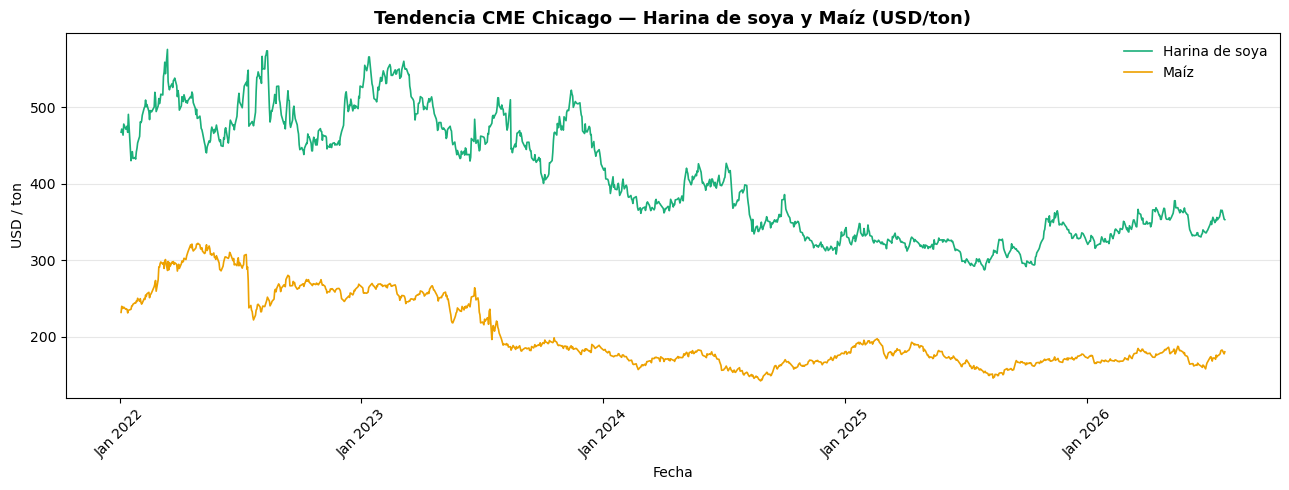

Harina de soya:
  Inicial: 467 | Final: 353
  Mínimo: 287 | Máximo: 575

Maíz:
  Inicial: 232 | Final: 181
  Mínimo: 143 | Máximo: 322


In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import sqlite3

DB_PATH = "mercado_hch.db"
with sqlite3.connect(DB_PATH) as con:
    df_cme = pd.read_sql("SELECT * FROM cme_diario ORDER BY fecha", con)

df_cme['fecha'] = pd.to_datetime(df_cme['fecha'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_cme['fecha'], df_cme['harina_soya_cme_usd_ton'],
        color='#1baf7a', linewidth=1.2, label='Harina de soya')
ax.plot(df_cme['fecha'], df_cme['grano_maiz_cme_usd_ton'],
        color='#eda100', linewidth=1.2, label='Maíz')

ax.set_title('Tendencia CME Chicago — Harina de soya y Maíz (USD/ton)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('USD / ton')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Harina de soya:")
print(f"  Inicial: {df_cme['harina_soya_cme_usd_ton'].iloc[0]:.0f} | Final: {df_cme['harina_soya_cme_usd_ton'].iloc[-1]:.0f}")
print(f"  Mínimo: {df_cme['harina_soya_cme_usd_ton'].min():.0f} | Máximo: {df_cme['harina_soya_cme_usd_ton'].max():.0f}")
print("\nMaíz:")
print(f"  Inicial: {df_cme['grano_maiz_cme_usd_ton'].iloc[0]:.0f} | Final: {df_cme['grano_maiz_cme_usd_ton'].iloc[-1]:.0f}")
print(f"  Mínimo: {df_cme['grano_maiz_cme_usd_ton'].min():.0f} | Máximo: {df_cme['grano_maiz_cme_usd_ton'].max():.0f}")

## BMC_precios

### 1.1 Entendimiento por tabla -BMC_precios

In [53]:
import sqlite3, pandas as pd

DB_PATH = "mercado_hch.db"
def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

# Volumen
n = query("SELECT COUNT(*) AS n FROM bmc_precios")['n'].iloc[0]
print(f"📊 bmc_precios: {n:,} filas")

# Esquema
print("\n📋 Esquema:")
print(query("PRAGMA table_info(bmc_precios)").to_string(index=False))

# Muestra
print("\n📄 Muestra (5 filas):")
print(query("SELECT * FROM bmc_precios ORDER BY fecha DESC LIMIT 5").to_string(index=False))

# Productos únicos y su volumen
print("\n📦 Registros por producto:")
print(query("""
    SELECT producto, COUNT(*) AS n, MIN(fecha) AS desde, MAX(fecha) AS hasta
    FROM bmc_precios GROUP BY producto ORDER BY n DESC
""").to_string(index=False))

📊 bmc_precios: 9,121 filas

📋 Esquema:
 cid           name    type  notnull dflt_value  pk
   0             id INTEGER        0       None   1
   1          fecha    TEXT        1       None   0
   2        n_rueda INTEGER        0       None   0
   3   producto_bmc    TEXT        1       None   0
   4       producto    TEXT        1       None   0
   5         unidad    TEXT        0       None   0
   6    cantidad_kg    REAL        0       None   0
   7      total_cop    REAL        0       None   0
   8  precio_cop_kg    REAL        0       None   0
   9 precio_usd_ton    REAL        0       None   0
  10            trm    REAL        0       None   0
  11 n_subastadores INTEGER        0       None   0
  12    archivo_pdf    TEXT        0       None   0

📄 Muestra (5 filas):
   id      fecha  n_rueda            producto_bmc              producto unidad  cantidad_kg    total_cop  precio_cop_kg  precio_usd_ton    trm  n_subastadores                                                     

### 1.2 Reglas de negocio -BMC_precios

In [66]:
df_bmc = query("SELECT * FROM bmc_precios")

print("="*60)
print("REGLA 1 — precio_cop_kg ≈ total_cop / cantidad_kg")
print("="*60)
df_r1 = df_bmc[(df_bmc['cantidad_kg'] > 0) & (df_bmc['total_cop'].notna()) & (df_bmc['precio_cop_kg'].notna())].copy()
df_r1['precio_calculado'] = df_r1['total_cop'] / df_r1['cantidad_kg']
df_r1['diff_pct'] = ((df_r1['precio_cop_kg'] - df_r1['precio_calculado']) / df_r1['precio_calculado'] * 100).abs()
inconsistentes_r1 = df_r1[df_r1['diff_pct'] > 5]  # tolerancia 5% por redondeos
print(f"Filas evaluadas: {len(df_r1)}")
print(f"Inconsistentes (>5% de diferencia): {len(inconsistentes_r1)}")

print("\n" + "="*60)
print("REGLA 2 — n_rueda: mismo número de rueda = misma fecha")
print("="*60)
df_bmc['anio'] = df_bmc['fecha'].str[:4]
r2_ajustada = df_bmc.dropna(subset=['n_rueda']).groupby(['n_rueda', 'anio'])['fecha'].nunique()
inconsistentes_r2_ajustada = r2_ajustada[r2_ajustada > 1]
print(f"Rueda+año con más de una fecha (error real): {len(inconsistentes_r2_ajustada)}")

print("\n" + "="*60)
print("REGLA 3 — precio_usd_ton ≈ (precio_cop_kg × 1000) / trm")
print("="*60)
df_r3 = df_bmc[(df_bmc['trm'] > 0) & (df_bmc['precio_cop_kg'].notna()) & (df_bmc['precio_usd_ton'].notna())].copy()
df_r3['usd_calculado'] = (df_r3['precio_cop_kg'] * 1000) / df_r3['trm']
df_r3['diff_pct'] = ((df_r3['precio_usd_ton'] - df_r3['usd_calculado']) / df_r3['usd_calculado'] * 100).abs()
inconsistentes_r3 = df_r3[df_r3['diff_pct'] > 1]  # tolerancia 1%, es cálculo directo
print(f"Filas evaluadas: {len(df_r3)}")
print(f"Inconsistentes (>1% de diferencia): {len(inconsistentes_r3)}")

print("\n" + "="*60)
print("REGLA 4 — fechas en rango razonable")
print("="*60)
hoy = pd.Timestamp.today().strftime('%Y-%m-%d')
fechas_invalidas_r4 = df_bmc[(df_bmc['fecha'] > hoy) | (df_bmc['fecha'] < '2022-01-01')]
print(f"Fechas fuera de rango: {len(fechas_invalidas_r4)}")

REGLA 1 — precio_cop_kg ≈ total_cop / cantidad_kg
Filas evaluadas: 9121
Inconsistentes (>5% de diferencia): 0

REGLA 2 — n_rueda: mismo número de rueda = misma fecha
Rueda+año con más de una fecha (error real): 2

REGLA 3 — precio_usd_ton ≈ (precio_cop_kg × 1000) / trm
Filas evaluadas: 9121
Inconsistentes (>1% de diferencia): 0

REGLA 4 — fechas en rango razonable
Fechas fuera de rango: 0


In [64]:
print(inconsistentes_r2_ajustada)

# Detalle de esos 2 casos
casos_r2 = inconsistentes_r2_ajustada.reset_index()
for _, row in casos_r2.iterrows():
    detalle = df_bmc[(df_bmc['n_rueda'] == row['n_rueda']) & (df_bmc['anio'] == row['anio'])][['fecha', 'n_rueda', 'archivo_pdf']].drop_duplicates()
    print(f"\nRueda {row['n_rueda']} - Año {row['anio']}:")
    print(detalle.to_string(index=False))

n_rueda  anio
128      2026    2
194      2025    2
Name: fecha, dtype: int64

Rueda 128 - Año 2026:
     fecha  n_rueda                                                                  archivo_pdf
2026-07-15      128                   BDR_128_DIARIO DE RUEDA N- 128 DEL 15 DE JULIO DE 2026.pdf
2026-07-14      128 BDR_128_ALCANCE A BOLETÍN DIARIO DE RUEDA N- 128 DEL 14 DE JULIO DE 2026.pdf

Rueda 194 - Año 2025:
     fecha  n_rueda                                                  archivo_pdf
2025-10-15      194 BDR_194_DIARIO DE RUEDA N- 194 DEL 15 DE OCTUBRE DE 2025.pdf
2025-10-17      194 BDR_196_DIARIO DE RUEDA N- 194 DEL 17 DE OCTUBRE DE 2025.pdf


### 1.3 Análisis descriptivo -BMC_precios

In [69]:
# ¿Han aparecido boletines después del 29 de mayo que NO incluyan estos 2 productos?
con_check = query("""
    SELECT DISTINCT fecha, archivo_pdf
    FROM bmc_precios
    WHERE fecha > '2026-05-29'
    ORDER BY fecha
    LIMIT 15
""")
print("Boletines posteriores al 29-mayo (muestra):")
print(con_check.to_string(index=False))

# ¿Cuántos productos distintos trae cada boletín reciente vs. uno de antes?
comparativo = query("""
    SELECT fecha, COUNT(DISTINCT producto) AS n_productos
    FROM bmc_precios
    WHERE fecha >= '2026-05-01'
    GROUP BY fecha
    ORDER BY fecha
""")
print("\nProductos distintos por boletín (mayo-julio 2026):")
print(comparativo.to_string(index=False))

Boletines posteriores al 29-mayo (muestra):
     fecha                                                 archivo_pdf
2026-06-03  BDR_103_DIARIO DE RUEDA N- 103 DEL 03 DE JUNIO DE 2026.pdf
2026-06-05  BDR_105_DIARIO DE RUEDA N- 105 DEL 05 DE JUNIO DE 2026.pdf
2026-06-10  BDR_107_DIARIO DE RUEDA N- 107 DEL 10 DE JUNIO DE 2026.pdf
2026-06-11  BDR_108_DIARIO DE RUEDA N- 108 DEL 11 DE JUNIO DE 2026.pdf
2026-06-12  BDR_109_DIARIO DE RUEDA N- 109 DEL 12 DE JUNIO DE 2026.pdf
2026-06-17  BDR_111_DIARIO DE RUEDA N- 111 DEL 17 DE JUNIO DE 2026.pdf
2026-06-18  BDR_112_DIARIO DE RUEDA N- 112 DEL 18 DE JUNIO DE 2026.pdf
2026-06-19  BDR_113_DIARIO DE RUEDA N- 113 DEL 19 DE JUNIO DE 2026.pdf
2026-06-22  BDR_114_DIARIO DE RUEDA N- 114 DEL 22 DE JUNIO DE 2026.pdf
2026-06-23  BDR_115_DIARIO DE RUEDA N- 115 DEL 23 DE JUNIO DE 2026.pdf
2026-06-25  BDR_117_DIARIO DE RUEDA N- 117 DEL 25 DE JUNIO DE 2026.pdf
2026-06-26  BDR_118_DIARIO DE RUEDA N- 118 DEL 26 DE JUNIO DE 2026.pdf
2026-07-01 BDR_120_DIARIO DE RUED

In [71]:
# ¿Cuál es el único producto que SÍ se captura en esos días de 1 fila?
un_producto = query("""
    SELECT fecha, producto, archivo_pdf
    FROM bmc_precios
    WHERE fecha BETWEEN '2026-06-03' AND '2026-07-23'
    ORDER BY fecha
""")
print(un_producto.to_string(index=False))

     fecha              producto                                                                  archivo_pdf
2026-06-03     concentrado_gatos                   BDR_103_DIARIO DE RUEDA N- 103 DEL 03 DE JUNIO DE 2026.pdf
2026-06-03    concentrado_perros                   BDR_103_DIARIO DE RUEDA N- 103 DEL 03 DE JUNIO DE 2026.pdf
2026-06-05    concentrado_perros                   BDR_105_DIARIO DE RUEDA N- 105 DEL 05 DE JUNIO DE 2026.pdf
2026-06-10 fosfato_monodicalcico                   BDR_107_DIARIO DE RUEDA N- 107 DEL 10 DE JUNIO DE 2026.pdf
2026-06-11         harina_sangre                   BDR_108_DIARIO DE RUEDA N- 108 DEL 11 DE JUNIO DE 2026.pdf
2026-06-12    concentrado_perros                   BDR_109_DIARIO DE RUEDA N- 109 DEL 12 DE JUNIO DE 2026.pdf
2026-06-17     concentrado_gatos                   BDR_111_DIARIO DE RUEDA N- 111 DEL 17 DE JUNIO DE 2026.pdf
2026-06-18    concentrado_perros                   BDR_112_DIARIO DE RUEDA N- 112 DEL 18 DE JUNIO DE 2026.pdf
2026-06-19

In [95]:
hch_gap = query("""
    SELECT fecha, precio_cop_kg, archivo_pdf
    FROM bmc_precios
    WHERE producto = 'HCH' AND fecha BETWEEN '2026-05-29' AND '2026-07-28'
    ORDER BY fecha
""")
print(f"Filas de HCH entre 29-may y 28-jul: {len(hch_gap)}")
print(hch_gap.to_string(index=False))

Filas de HCH entre 29-may y 28-jul: 17
     fecha  precio_cop_kg                                                                  archivo_pdf
2026-05-29        1594.00                    BDR_100_DIARIO DE RUEDA N- 100 DEL 29 DE MAYO DE 2026.pdf
2026-06-03        1791.08                   BDR_103_DIARIO DE RUEDA N- 103 DEL 03 DE JUNIO DE 2026.pdf
2026-06-10        1988.95                   BDR_107_DIARIO DE RUEDA N- 107 DEL 10 DE JUNIO DE 2026.pdf
2026-06-11        1804.76                   BDR_108_DIARIO DE RUEDA N- 108 DEL 11 DE JUNIO DE 2026.pdf
2026-06-12        1893.28                   BDR_109_DIARIO DE RUEDA N- 109 DEL 12 DE JUNIO DE 2026.pdf
2026-06-18        1874.94                   BDR_112_DIARIO DE RUEDA N- 112 DEL 18 DE JUNIO DE 2026.pdf
2026-06-19        1855.62                   BDR_113_DIARIO DE RUEDA N- 113 DEL 19 DE JUNIO DE 2026.pdf
2026-06-22        1990.10                   BDR_114_DIARIO DE RUEDA N- 114 DEL 22 DE JUNIO DE 2026.pdf
2026-06-23        1602.95         

Hallazgo resuelto — hueco de cobertura BMC (3-jun a 23-jul 2026)

22 boletines de ese rango se procesaron originalmente con una fracción de sus 
datos reales (1-2 productos en vez de 7-14), por un fallo silencioso en la 
corrida automática en lote de esa mañana. Se confirmó que el código de 
extracción funciona correctamente de forma aislada. Se reprocesaron los 22 
boletines afectados con INSERT OR IGNORE — 147 filas nuevas recuperadas, 
incluyendo 15 registros de HCH (antes: 2).

In [113]:
con = sqlite3.connect(DB_PATH)
check = pd.read_sql("""
    SELECT DISTINCT producto_bmc FROM bmc_precios
    WHERE fecha > '2026-05-29'
    ORDER BY producto_bmc
""", con)
con.close()
print(check.to_string(index=False))

                    producto_bmc
  ALIMENTO CONCENTRADO PARA AVES
ALIMENTO CONCENTRADO PARA CERDOS
 ALIMENTO CONCENTRADO PARA GATOS
ALIMENTO CONCENTRADO PARA PERROS
           FOSFATO MONODICALCICO
         HARINA DE CARNE Y HUESO
                 HARINA DE HUESO
                 HARINA DE PLUMA
                HARINA DE SANGRE
              HARINA DE VISCERAS
                     SEBO DE RES
           SUBPRODUCTOS CARNICOS
         TORTA DE SOYA IMPORTADA


Hallazgo: 

"harina_carne" (producto no incluido en PRODUCTOS_OBJETIVO original, 
capturado por coincidencia parcial de texto) dejó de aparecer en los boletines 
BMC a partir de 2026-05-29. Confirmado que no es error de OCR/scraper — el 
producto simplemente no se transó en el mercado en ese período. No afecta el 
análisis de HCH ni de los 13 productos objetivo del proyecto.

In [99]:
resumen_bmc = query("""
    SELECT producto,
           COUNT(*) AS n,
           ROUND(AVG(precio_cop_kg), 0) AS precio_promedio,
           ROUND(MIN(precio_cop_kg), 0) AS precio_minimo,
           ROUND(MAX(precio_cop_kg), 0) AS precio_maximo,
           ROUND(AVG(cantidad_kg), 0) AS cantidad_prom_kg,
           MIN(fecha) AS desde,
           MAX(fecha) AS hasta
    FROM bmc_precios
    GROUP BY producto
    ORDER BY n DESC
""")
print(resumen_bmc.to_string(index=False))

             producto   n  precio_promedio  precio_minimo  precio_maximo  cantidad_prom_kg      desde      hasta
             sebo_res 872           3115.0          242.0         6721.0          429467.0 2022-09-12 2026-07-28
    concentrado_gatos 822           6104.0         1246.0        20223.0          201052.0 2022-09-12 2026-07-28
   concentrado_perros 784           3912.0         1406.0        20000.0          640143.0 2022-09-12 2026-07-28
subproductos_carnicos 775            625.0           11.0        29110.0          199927.0 2022-09-12 2026-07-28
                  HCH 755           2298.0         1210.0         5544.0          204815.0 2022-09-12 2026-07-28
 torta_soya_importada 738           2068.0         1320.0         3440.0         1498172.0 2022-09-12 2026-07-28
         harina_hueso 719           2164.0          928.0         5005.0           52356.0 2022-09-12 2026-07-28
   concentrado_cerdos 681           2098.0         1005.0         2991.0         5110226.0 2022-

Los 14 productos capturados muestran precios en rangos 
coherentes con el mercado real (mayoría entre 2,000 y 6,000 COP/kg), sin 
valores residuales de los bugs de OCR ya corregidos. 

- `subproductos_carnicos` es el más disperso (min 11, max 29,110 COP/kg) — verificado que son datos 
reales, no errores: lotes pequeños se transan a precio unitario mucho más 
alto que lotes grandes, un comportamiento normal de mercado de rueda. 
- `harina_carne` (producto no perteneciente a la lista objetivo del proyecto) dejó de transarse después del 29-mayo-2026 — confirmado como discontinuación real del mercado, no error de captura.

C:\Users\nvind\AppData\Local\Temp\ipykernel_33260\4076127276.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_boxplot, labels=productos, showfliers=True)


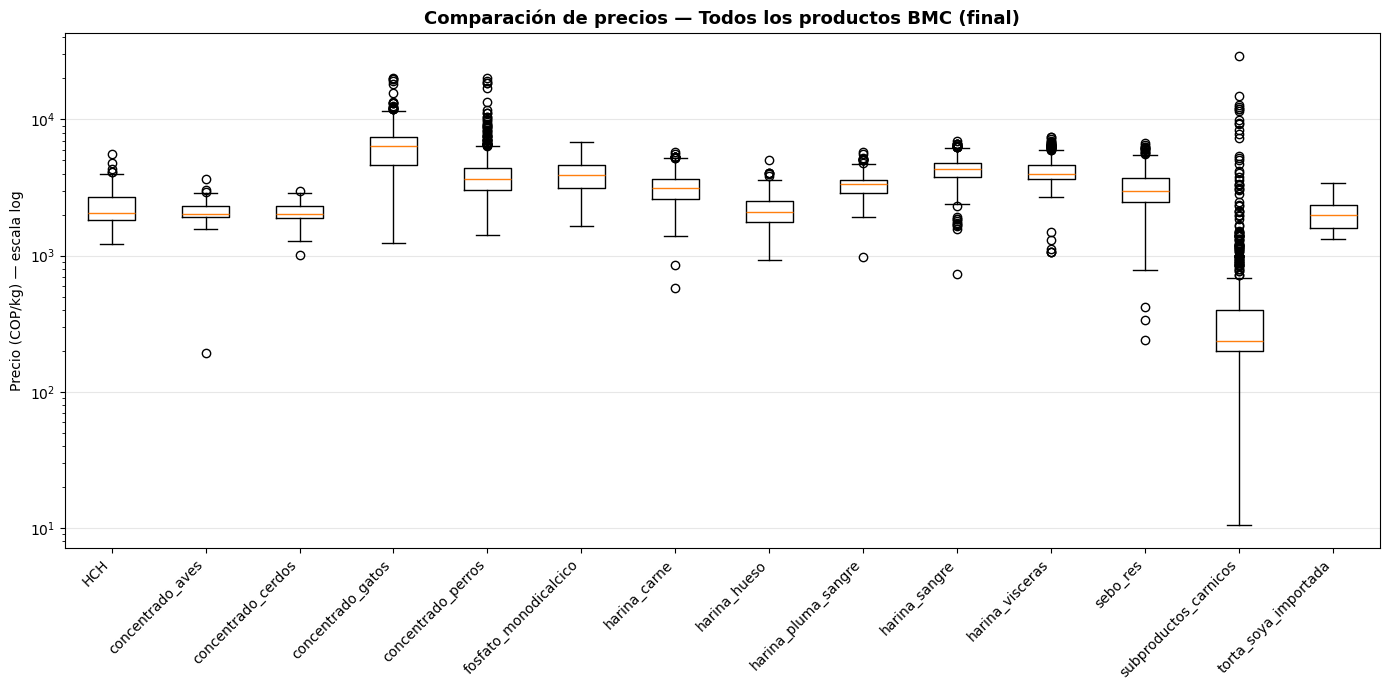

In [101]:
import matplotlib.pyplot as plt

df_bmc_todos = query("SELECT producto, precio_cop_kg FROM bmc_precios WHERE precio_cop_kg IS NOT NULL")
productos = sorted(df_bmc_todos['producto'].unique())
datos_boxplot = [df_bmc_todos[df_bmc_todos['producto'] == p]['precio_cop_kg'].dropna() for p in productos]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(datos_boxplot, labels=productos, showfliers=True)
ax.set_ylabel('Precio (COP/kg) — escala log')
ax.set_yscale('log')
ax.set_title('Comparación de precios — Todos los productos BMC (final)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

La mayoría de productos presenta distribuciones compactas 
en escala logarítmica (1,000–7,000 COP/kg), reflejando un mercado de precios 
relativamente estable. 
- `subproductos_carnicos` muestra la caja más ancha y 
el mayor número de valores atípicos — coherente con ser el producto de menor 
precio base, donde las variaciones porcentuales por tamaño de lote se notan 
más.
- HCH se ubica en el rango medio-bajo de precios del grupo, sin outliers 
severos, señal de una serie limpia tras las correcciones aplicadas.

In [107]:
con = sqlite3.connect(DB_PATH)
nuevo_outlier = pd.read_sql("""
    SELECT fecha, archivo_pdf, cantidad_kg, total_cop, precio_cop_kg
    FROM bmc_precios
    WHERE producto = 'subproductos_carnicos' AND precio_cop_kg > 15000
    ORDER BY precio_cop_kg DESC
""", con)
con.close()
print(nuevo_outlier.to_string(index=False))

     fecha                                                archivo_pdf  cantidad_kg  total_cop  precio_cop_kg
2026-07-02 BDR_121_DIARIO DE RUEDA N- 121 DEL 02 DE JULIO DE 2026.pdf       280.03  8151573.0       29109.85


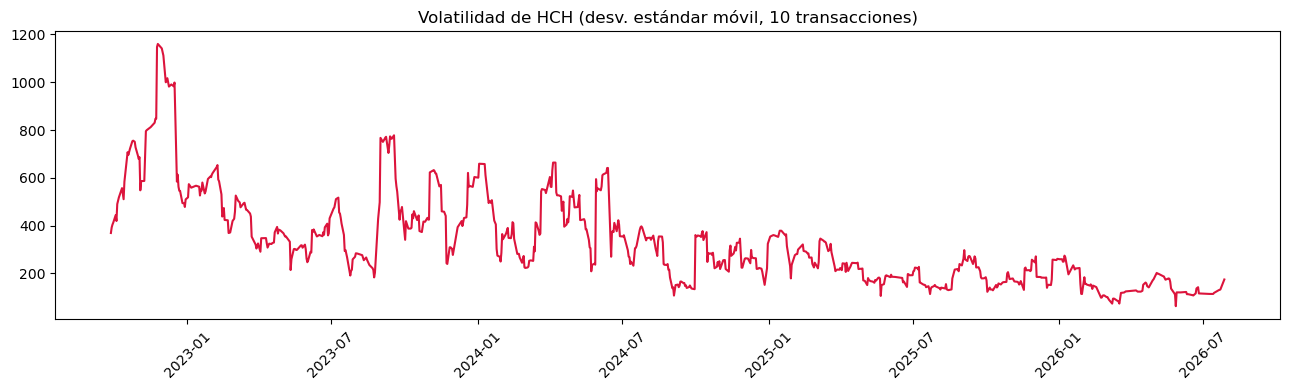

In [103]:
con = sqlite3.connect(DB_PATH)
df_hch = pd.read_sql("SELECT fecha, precio_cop_kg FROM bmc_precios WHERE producto = 'HCH' ORDER BY fecha", con)
con.close()

df_hch['fecha'] = pd.to_datetime(df_hch['fecha'])
df_hch = df_hch.set_index('fecha')

# Volatilidad móvil (ventana de 10 transacciones, ya que no es diario continuo)
df_hch['volatilidad'] = df_hch['precio_cop_kg'].rolling(10).std()

fig, ax = plt.subplots(figsize=(13,4))
ax.plot(df_hch.index, df_hch['volatilidad'], color='crimson')
ax.set_title('Volatilidad de HCH (desv. estándar móvil, 10 transacciones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El precio de HCH muestra una tendencia descendente sostenida 
desde 2022 (~3,000 COP/kg) hasta 2026 (~1,800 COP/kg), coincidiendo con la 
apreciación del peso colombiano en el mismo período. 

La volatilidad (desviación 
estándar móvil) confirma este patrón: los picos más altos (1,000–1,150) se 
concentran en 2022–2023, época de mayor incertidumbre cambiaria, mientras que 
desde 2024 la volatilidad se estabiliza en niveles bajos (100–300). 

Esto sugiere 
que el mercado de HCH se ha vuelto más predecible en los últimos dos años, 
favorable para la confiabilidad del modelo de forecasting.

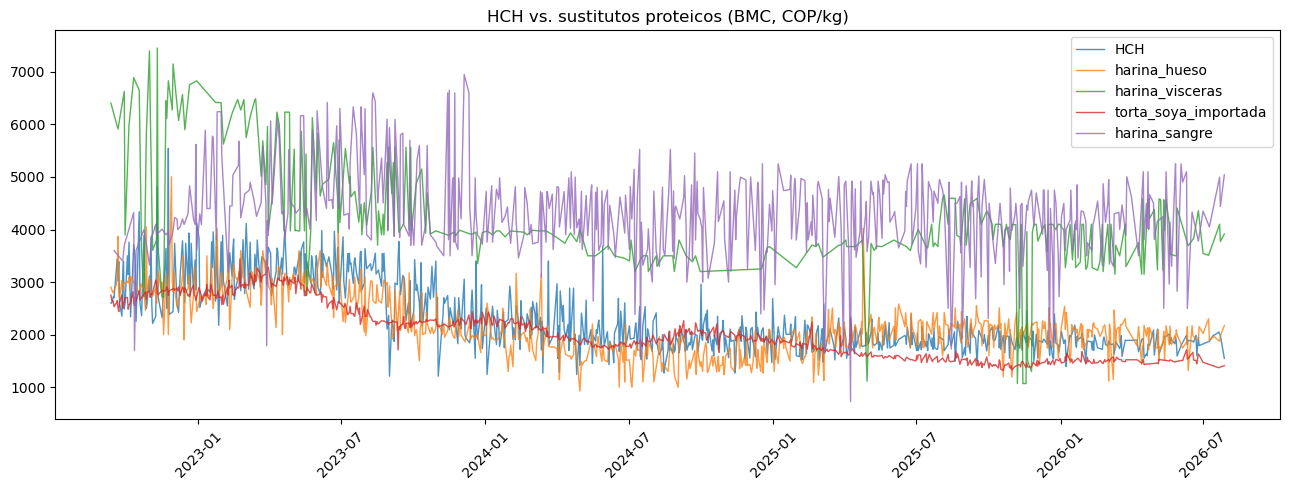

In [105]:
con = sqlite3.connect(DB_PATH)
df_sustitutos = pd.read_sql("""
    SELECT fecha, producto, precio_cop_kg
    FROM bmc_precios
    WHERE producto IN ('HCH', 'harina_sangre', 'harina_visceras', 'harina_hueso', 'torta_soya_importada')
    ORDER BY fecha
""", con)
con.close()

df_sustitutos['fecha'] = pd.to_datetime(df_sustitutos['fecha'])
fig, ax = plt.subplots(figsize=(13,5))
for prod in df_sustitutos['producto'].unique():
    sub = df_sustitutos[df_sustitutos['producto']==prod]
    ax.plot(sub['fecha'], sub['precio_cop_kg'], label=prod, linewidth=1, alpha=0.8)
ax.legend()
ax.set_title('HCH vs. sustitutos proteicos (BMC, COP/kg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

HCH y harina_hueso se mueven de forma casi idéntica durante 
todo el período — esperable dada su composición similar. 

- harina_visceras y 
harina_sangre se mantienen consistentemente por encima (3,000–7,000 COP/kg 
frente a 1,500–3,000 de HCH), posicionando a HCH como una de las opciones 
proteicas más económicas del grupo. 

- torta_soya_importada, pese a ser un 
sustituto de referencia internacional, se mantiene en niveles similares o 
levemente inferiores a HCH — relevante para el análisis de sustitución (2.a/2.b), 
ya que sugiere que la soya importada es competitiva en precio incluso sin 
choques cambiarios extremos.

In [115]:
con = sqlite3.connect(DB_PATH)
df_est = pd.read_sql("SELECT fecha, precio_cop_kg FROM bmc_precios WHERE producto = 'HCH'", con)
con.close()

df_est['mes'] = pd.to_datetime(df_est['fecha']).dt.month
resumen_mensual = df_est.groupby('mes')['precio_cop_kg'].agg(['mean','std','count']).round(1)
print(resumen_mensual)

       mean    std  count
mes                      
1    2293.5  623.2     59
2    2261.4  622.4     66
3    2327.3  699.0     63
4    2250.0  680.6     62
5    2318.3  660.7     68
6    2339.8  688.8     55
7    2293.9  665.6     65
8    2240.7  697.1     46
9    2255.4  566.4     68
10   2399.3  630.4     72
11   2271.3  723.3     63
12   2304.5  681.6     68


No se observa un patrón estacional claro en el precio de HCH 
los promedios mensuales varían solo ~7% entre el mes más bajo (agosto, 2,240) 
y el más alto (octubre, 2,399), una diferencia pequeña frente a la desviación 
estándar de cada mes (~600–700). El precio de HCH 
parece responder más a choques puntuales (TRM, oferta/demanda específica) que 
a un ciclo anual repetible. Esto tiene una implicación para el modelo de 
predicción: no vale la pena incluir "mes del año" como variable predictora 
por sí sola.

## Comtrade

### 1.1 Entendimiento por tabla - Comtrade

In [173]:
import sqlite3, pandas as pd

DB_PATH = "mercado_hch.db"
def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

n = query("SELECT COUNT(*) AS n FROM importaciones")['n'].iloc[0]
print(f"📊 importaciones: {n:,} filas")
print(query("PRAGMA table_info(importaciones)").to_string(index=False))
print()

print("📄 Muestra importaciones (cruda):")
print(query("SELECT * FROM importaciones ORDER BY refYear DESC LIMIT 5").to_string(index=False))

print("\n📦 Registros por producto, año y país:")
print(query("""
    SELECT producto, refYear AS anio, pais_origen, COUNT(*) AS n
    FROM importaciones
    GROUP BY producto, refYear, pais_origen
    ORDER BY producto, anio
""").to_string(index=False))

📊 importaciones: 2,181 filas
 cid           name    type  notnull dflt_value  pk
   0         period    TEXT        0       None   0
   1        refYear INTEGER        0       None   0
   2        cmdCode    TEXT        0       None   0
   3    partnerCode INTEGER        0       None   0
   4       cifvalue    REAL        0       None   0
   5         netWgt    REAL        0       None   0
   6            qty    REAL        0       None   0
   7    qtyUnitAbbr    TEXT        0       None   0
   8    pais_origen    TEXT        0       None   0
   9       producto    TEXT        0       None   0
  10     netWgt_ton    REAL        0       None   0
  11 precio_usd_ton    REAL        0       None   0
  12 fecha_scraping    TEXT        0       None   0

📄 Muestra importaciones (cruda):
period  refYear cmdCode  partnerCode   cifvalue      netWgt         qty qtyUnitAbbr pais_origen producto  netWgt_ton  precio_usd_ton fecha_scraping
  2025     2025  230110           76 7167746.90 15447980.64 1

Cada fila representa el monto y volumen que Colombia importó de un producto específico (HCH, fosfato, grano de soya, etc.), desde un país de origen específico, durante un año calendario específico.

### Nota metodológica — Naturaleza del precio en `importaciones` (Comtrade)

El campo `precio_usd_ton` se calcula como `cifvalue / netWgt_ton`, donde `cifvalue` 
es un valor **CIF** (Cost, Insurance, Freight). Esto significa que el precio 
implícito **no es un precio puesto en fábrica** (FOB) — ya incluye el costo de 
transporte internacional y el seguro del envío hasta la frontera colombiana.

**Implicación para el análisis:** dos países pueden tener el mismo precio de 
producción, pero si uno está geográficamente más lejos de Colombia (más flete) 
o el envío implica mayor riesgo (más seguro), su `precio_usd_ton` va a aparecer 
más alto — sin que eso refleje una diferencia real en el costo del producto 
en sí. Por ejemplo, España e Italia podrían mostrar precios más altos que 
Brasil o Paraguay simplemente por la distancia, no porque el insumo sea de 
mejor calidad o más escaso.

**Consideración para comparaciones futuras (Analítica 1.0 y 2.b):**
- Comparar el precio CIF de Comtrade directamente contra el precio doméstico 
  de BMC (que no tiene componente de flete internacional) puede sobreestimar 
  la diferencia real de costo entre producir/comprar HCH localmente vs. importarla.
- Al analizar "concentración de proveedores" o "riesgo de importación" (Análisis 
  2.b), conviene tener presente que el precio por país no es directamente 
  comparable entre sí sin considerar la distancia — un precio más alto desde 
  un país lejano no necesariamente significa un producto más caro en origen.
- Si se quisiera aislar el efecto de flete/seguro, sería necesario un dato de 
  precio FOB (no disponible en el API gratuito de Comtrade) o al menos 
  documentar esta limitación al presentar comparaciones de precio por país.

### 1.2. Reglas de negocio -Comtrade

In [180]:
con = sqlite3.connect(DB_PATH)
df_comtrade = pd.read_sql("SELECT * FROM importaciones", con)
con.close()

print("="*60)
print("REGLA 1 — Consistencia: precio_usd_ton ≈ cifvalue / netWgt_ton")
print("="*60)
df_comtrade['precio_calculado'] = df_comtrade['cifvalue'] / df_comtrade['netWgt_ton']
df_comtrade['diff_pct'] = ((df_comtrade['precio_usd_ton'] - df_comtrade['precio_calculado']) / df_comtrade['precio_calculado'] * 100).abs()
inconsistentes = df_comtrade[df_comtrade['diff_pct'] > 1]
print(f"Filas evaluadas: {len(df_comtrade)}")
print(f"Inconsistentes (>1%): {len(inconsistentes)}")

print("\n" + "="*60)
print("REGLA 2 — Años en rango razonable (2020-2026)")
print("="*60)
fuera_rango = df_comtrade[(df_comtrade['refYear'] < 2020) | (df_comtrade['refYear'] > 2026)]
print(f"Filas fuera de rango: {len(fuera_rango)}")

print("\n" + "="*60)
print("REGLA 3 — Duplicados exactos (mismo producto, año, país, valor)")
print("="*60)
dup = df_comtrade.duplicated(subset=['producto','refYear','partnerCode','cifvalue','netWgt']).sum()
print(f"Filas duplicadas: {dup}")

print("\n" + "="*60)
print("REGLA 4 — Valores negativos o cero en campos numéricos clave")
print("="*60)
invalidos = df_comtrade[
    (df_comtrade['cifvalue'] <= 0) | (df_comtrade['netWgt'] <= 0)
]
print(f"Filas con valores ≤0: {len(invalidos)}")

REGLA 1 — Consistencia: precio_usd_ton ≈ cifvalue / netWgt_ton
Filas evaluadas: 2181
Inconsistentes (>1%): 0

REGLA 2 — Años en rango razonable (2020-2026)
Filas fuera de rango: 0

REGLA 3 — Duplicados exactos (mismo producto, año, país, valor)
Filas duplicadas: 1246

REGLA 4 — Valores negativos o cero en campos numéricos clave
Filas con valores ≤0: 0


In [182]:
# Ver un grupo de "duplicados" completo, con TODAS las columnas, para detectar qué varía
duplicados_mask = df_comtrade.duplicated(subset=['producto','refYear','partnerCode','cifvalue','netWgt'], keep=False)
grupo_ejemplo = df_comtrade[duplicados_mask].sort_values(['producto','refYear','partnerCode']).head(20)
print(grupo_ejemplo.to_string(index=False))

period  refYear cmdCode  partnerCode   cifvalue     netWgt        qty qtyUnitAbbr      pais_origen producto  netWgt_ton  precio_usd_ton fecha_scraping  precio_calculado  diff_pct
  2020     2020  230110            0 7707675.89 17353497.6 17353497.6        None Mundo (agregado)      HCH  17353.4976      444.156911     2026-07-30        444.156911       0.0
  2020     2020  230110            0    5750.00     1020.0     1020.0        None Mundo (agregado)      HCH      1.0200     5637.254902     2026-07-30       5637.254902       0.0
  2020     2020  230110            0   62641.94   131395.0   131395.0        None Mundo (agregado)      HCH    131.3950      476.745234     2026-07-30        476.745234       0.0
  2020     2020  230110            0 1413635.44  3306790.0  3306790.0        None Mundo (agregado)      HCH   3306.7900      427.494773     2026-07-30        427.494773       0.0
  2020     2020  230110            0    5750.00     1020.0     1020.0        None Mundo (agregado)      H

In [184]:
# Tomar un grupo específico y ver todas sus columnas completas
grupo = df_comtrade[duplicados_mask].sort_values(['producto','refYear','partnerCode','cifvalue'])
primer_grupo = grupo[
    (grupo['producto'] == grupo['producto'].iloc[0]) &
    (grupo['refYear'] == grupo['refYear'].iloc[0]) &
    (grupo['partnerCode'] == grupo['partnerCode'].iloc[0]) &
    (grupo['cifvalue'] == grupo['cifvalue'].iloc[0])
]
print(f"Filas en este grupo específico: {len(primer_grupo)}")
print(primer_grupo.T)  # transpuesto para ver todas las columnas claramente

Filas en este grupo específico: 2
                                55                70
period                        2020              2020
refYear                       2020              2020
cmdCode                     230110            230110
partnerCode                      0                 0
cifvalue                    5750.0            5750.0
netWgt                      1020.0            1020.0
qty                         1020.0            1020.0
qtyUnitAbbr                   None              None
pais_origen       Mundo (agregado)  Mundo (agregado)
producto                       HCH               HCH
netWgt_ton                    1.02              1.02
precio_usd_ton         5637.254902       5637.254902
fecha_scraping          2026-07-30        2026-07-30
precio_calculado       5637.254902       5637.254902
diff_pct                       0.0               0.0


In [186]:
print(f"Filas antes de eliminar duplicados: {len(df_comtrade)}")

df_comtrade_sin_dup = df_comtrade.drop_duplicates(
    subset=['producto','refYear','partnerCode','cifvalue','netWgt'],
    keep='first'
)

print(f"Filas después de eliminar duplicados: {len(df_comtrade_sin_dup)}")
print(f"Duplicados eliminados: {len(df_comtrade) - len(df_comtrade_sin_dup)}")

# Guardar la versión limpia
con = sqlite3.connect(DB_PATH)
df_comtrade_sin_dup.drop(columns=['precio_calculado', 'diff_pct']).to_sql(
    "importaciones", con, if_exists="replace", index=False
)
con.close()
print("✅ Tabla 'importaciones' actualizada sin duplicados")

Filas antes de eliminar duplicados: 2181
Filas después de eliminar duplicados: 935
Duplicados eliminados: 1246
✅ Tabla 'importaciones' actualizada sin duplicados


In [188]:
con = sqlite3.connect(DB_PATH)
df_comtrade = pd.read_sql("SELECT * FROM importaciones", con)
con.close()

print("="*60)
print("REGLA 1 — Consistencia: precio_usd_ton ≈ cifvalue / netWgt_ton")
print("="*60)
df_comtrade['precio_calculado'] = df_comtrade['cifvalue'] / df_comtrade['netWgt_ton']
df_comtrade['diff_pct'] = ((df_comtrade['precio_usd_ton'] - df_comtrade['precio_calculado']) / df_comtrade['precio_calculado'] * 100).abs()
inconsistentes = df_comtrade[df_comtrade['diff_pct'] > 1]
print(f"Filas evaluadas: {len(df_comtrade)}")
print(f"Inconsistentes (>1%): {len(inconsistentes)}")

print("\n" + "="*60)
print("REGLA 2 — Años en rango razonable (2020-2026)")
print("="*60)
fuera_rango = df_comtrade[(df_comtrade['refYear'] < 2020) | (df_comtrade['refYear'] > 2026)]
print(f"Filas fuera de rango: {len(fuera_rango)}")

print("\n" + "="*60)
print("REGLA 3 — Duplicados exactos (confirmación tras limpieza)")
print("="*60)
dup = df_comtrade.duplicated(subset=['producto','refYear','partnerCode','cifvalue','netWgt']).sum()
print(f"Filas duplicadas: {dup}")

print("\n" + "="*60)
print("REGLA 4 — Valores negativos o cero en campos numéricos clave")
print("="*60)
invalidos = df_comtrade[(df_comtrade['cifvalue'] <= 0) | (df_comtrade['netWgt'] <= 0)]
print(f"Filas con valores ≤0: {len(invalidos)}")

REGLA 1 — Consistencia: precio_usd_ton ≈ cifvalue / netWgt_ton
Filas evaluadas: 935
Inconsistentes (>1%): 0

REGLA 2 — Años en rango razonable (2020-2026)
Filas fuera de rango: 0

REGLA 3 — Duplicados exactos (confirmación tras limpieza)
Filas duplicadas: 0

REGLA 4 — Valores negativos o cero en campos numéricos clave
Filas con valores ≤0: 0


### 1.3 Análisis descriptivo - COmtrade

In [193]:
con = sqlite3.connect(DB_PATH)
df_comtrade = pd.read_sql("SELECT * FROM importaciones", con)
con.close()

df_mundo = df_comtrade[df_comtrade['pais_origen'] == 'Mundo (agregado)']

resumen_mundo = df_mundo.groupby(['producto', 'refYear']).agg(
    n_filas=('cifvalue', 'count'),
    cantidad_ton_total=('netWgt_ton', 'sum'),
    cantidad_ton_promedio=('netWgt_ton', 'mean'),
    precio_min=('precio_usd_ton', 'min'),
    precio_max=('precio_usd_ton', 'max'),
    precio_mediana=('precio_usd_ton', 'median'),
).round(1)

print(resumen_mundo.to_string())

                        n_filas  cantidad_ton_total  cantidad_ton_promedio  precio_min  precio_max  precio_mediana
producto       refYear                                                                                            
HCH            2020          24            198054.7                 8252.3       367.9     14000.0           715.8
               2021          26            228243.3                 8778.6       507.9     15203.1           796.4
               2022          20            179679.4                 8984.0       637.9     10978.3          1065.7
               2023          24            178536.0                 7439.0       614.9     92685.4          1136.6
               2024          22            185376.9                 8426.2       426.8     12891.0          1039.2
               2025          16            254720.8                15920.1       342.8      6784.8           820.3
fosfato        2020          18             23796.9                 1322.1      

In [195]:
con = sqlite3.connect(DB_PATH)
df_comtrade = pd.read_sql("SELECT * FROM importaciones", con)
con.close()

# ── 1. Precio (mediana, más robusta) — usando solo "Mundo agregado" ──────
precio_anual_mediana = df_comtrade[df_comtrade['pais_origen'] == 'Mundo (agregado)'].groupby(
    ['producto', 'refYear']
)['precio_usd_ton'].median().round(1).unstack('refYear')

print("Precio MEDIANO USD/ton por producto y año (agregado mundial):")
print(precio_anual_mediana)

# ── 2. Disponibilidad — número de países proveedores distintos ───────────
NO_PAISES = ['Mundo (agregado)', 'Áreas no especificadas', 'Zonas Francas', 'Otros de Asia (no especificado)']
df_paises_reales = df_comtrade[~df_comtrade['pais_origen'].isin(NO_PAISES)]

disponibilidad = df_paises_reales.groupby(['producto', 'refYear'])['pais_origen'].nunique().unstack('refYear')
print("\nNúmero de países proveedores distintos, por producto y año:")
print(disponibilidad)

# ── 3. Riesgo de concentración — % del proveedor principal ───────────────
def concentracion_top_pais(grupo):
    total = grupo['netWgt_ton'].sum()
    if total == 0:
        return None
    top = grupo.groupby('pais_origen')['netWgt_ton'].sum().max()
    return round(top / total * 100, 1)

concentracion = df_paises_reales.groupby(['producto', 'refYear']).apply(
    concentracion_top_pais, include_groups=False
).unstack('refYear')

print("\n% del volumen total que representa el país proveedor principal:")
print(concentracion)

ultimo_anio = df_paises_reales['refYear'].max()
print(f"\nPaís líder por producto en {ultimo_anio}:")
for prod in df_paises_reales['producto'].unique():
    sub = df_paises_reales[(df_paises_reales['producto']==prod) & (df_paises_reales['refYear']==ultimo_anio)]
    if len(sub) > 0:
        lider = sub.groupby('pais_origen')['netWgt_ton'].sum().idxmax()
        print(f"  {prod}: {lider}")

Precio MEDIANO USD/ton por producto y año (agregado mundial):
refYear           2020    2021    2022    2023    2024    2025
producto                                                      
HCH              715.8   796.4  1065.7  1136.6  1039.2   820.3
fosfato          739.9  4179.3  1444.7  1610.4  4918.5  1080.5
grano_soya       404.5   567.9  2514.4   652.0   522.6  1364.4
harina_pescado  1177.7  1189.2  1504.3  1613.8  1515.9  1372.7
harina_soya        NaN     NaN  3697.2  1537.4  9247.7  9969.6

Número de países proveedores distintos, por producto y año:
refYear         2020  2021  2022  2023  2024  2025
producto                                          
HCH              7.0   9.0   7.0   6.0   7.0   7.0
fosfato         11.0  12.0  15.0  12.0  10.0  13.0
grano_soya       4.0   3.0   3.0   3.0   4.0   2.0
harina_pescado   4.0   5.0   5.0   4.0   4.0   4.0
harina_soya      NaN   NaN   2.0   1.0   2.0   1.0

% del volumen total que representa el país proveedor principal:
refYear       

Hallazgos clave del 1.3 de F4

1. Riesgo de concentración crítico en grano_soya — 100% del volumen viene de un solo país (EE.UU.) en 4 de 6 años, con solo 2-4 proveedores distintos en total. Este es el insumo con mayor riesgo de importación de todos — cualquier choque con EE.UU. (arancel, sequía, política comercial) dejaría a Colombia sin alternativa inmediata.

2. HCH muestra concentración creciente y preocupante — pasó de 51% (2020) a 78.5% (2025) de dependencia de un solo país (Brasil). La tendencia va empeorando año a año: cada vez menos diversificado.

3. fosfato es el más diversificado (10-15 países proveedores), pero con un salto raro en concentración en 2023 (91.6%) — vale la pena anotarlo como posible anomalía puntual de ese año, no tendencia.

4. harina_soya confirma ser insignificante — 1-2 proveedores, y como ya vimos, volumen casi nulo (0.1 ton en 2024-2025). Refuerza la recomendación de excluirla o marcarla como no comercialmente relevante.

5. Precios medianos ya coherentes con lo esperado: HCH ~700-1,140 USD/ton (consistente con el rango que viste en BMC convertido), fosfato ~740-4,900 (con variabilidad real, no artefactos), grano de soya ~400-2,500, harina de pescado el más estable (1,180-1,610).

## ingredientes_comparacion

### 1.1 Entendimiento — F5 (ingredientes_comparacion)

In [205]:
con = sqlite3.connect(DB_PATH)
n = pd.read_sql("SELECT COUNT(*) AS n FROM ingredientes_comparacion", con)['n'].iloc[0]
print(f"📊 ingredientes_comparacion: {n} filas")
print(pd.read_sql("PRAGMA table_info(ingredientes_comparacion)", con).to_string(index=False))
print()
print(pd.read_sql("SELECT * FROM ingredientes_comparacion", con).to_string(index=False))
con.close()

📊 ingredientes_comparacion: 10 filas
 cid                       name type  notnull dflt_value  pk
   0                     insumo TEXT        0       None   0
   1            Categoria FEDNA TEXT        0       None   0
   2         Proteina bruta (%) REAL        0       None   0
   3                P total (%) REAL        0       None   0
   4           P disponible (%) REAL        0       None   0
   5 Digestibilidad Porcino (%) REAL        0       None   0
   6    Digestibilidad Aves (%) REAL        0       None   0
   7                      Notas TEXT        0       None   0
   8              Fuente (link) TEXT        0       None   0
   9         precio_usd_ton_bmc REAL        0       None   0
  10           fecha_precio_bmc TEXT        0       None   0
  11       anio_precio_comtrade REAL        0       None   0
  12    precio_usd_ton_comtrade REAL        0       None   0
  13       n_paises_proveedores REAL        0       None   0
  14 pct_concentracion_top_pais REAL        0   

Cada fila es una ficha comparativa de un insumo proteico/mineral candidato a sustituir o competir con HCH en la formulación de alimento balanceado — con su composición nutricional (fija, tabulada por FEDNA), su precio más reciente (variable, tomado de BMC o Comtrade según de dónde se abastece principalmente), y su perfil de riesgo de abastecimiento (solo aplica a insumos importados, calculado desde Comtrade)

### 1.2 Reglas de negocio — F5 (ingredientes_comparacion)

In [208]:
con = sqlite3.connect(DB_PATH)
df_ing = pd.read_sql("SELECT * FROM ingredientes_comparacion", con)
con.close()

print("="*60)
print("REGLA 1 — Porcentajes dentro de rango válido (0-100%)")
print("="*60)
cols_pct = ['Proteina bruta (%)', 'P total (%)', 'P disponible (%)',
            'Digestibilidad Porcino (%)', 'Digestibilidad Aves (%)',
            'pct_concentracion_top_pais']
for col in cols_pct:
    fuera = df_ing[(df_ing[col] < 0) | (df_ing[col] > 100)]
    print(f"{col}: {len(fuera)} valores fuera de 0-100%")

print("\n" + "="*60)
print("REGLA 2 — P disponible no puede superar P total")
print("="*60)
inconsistente_p = df_ing[df_ing['P disponible (%)'] > df_ing['P total (%)']]
print(f"Filas con P disponible > P total: {len(inconsistente_p)}")
if len(inconsistente_p) > 0:
    print(inconsistente_p[['insumo', 'P total (%)', 'P disponible (%)']])

print("\n" + "="*60)
print("REGLA 3 — Precios positivos")
print("="*60)
precios_invalidos = df_ing[
    ((df_ing['precio_usd_ton_bmc'].notna()) & (df_ing['precio_usd_ton_bmc'] <= 0)) |
    ((df_ing['precio_usd_ton_comtrade'].notna()) & (df_ing['precio_usd_ton_comtrade'] <= 0))
]
print(f"Filas con precio ≤0: {len(precios_invalidos)}")

print("\n" + "="*60)
print("REGLA 4 — Coherencia disponibilidad/riesgo")
print("="*60)
# Si hay 1 solo país proveedor, la concentración debe ser 100%
un_pais = df_ing[df_ing['n_paises_proveedores'] == 1]
inconsistente_conc = un_pais[un_pais['pct_concentracion_top_pais'] != 100.0]
print(f"Filas con 1 país proveedor pero concentración ≠100%: {len(inconsistente_conc)}")

print("\n" + "="*60)
print("REGLA 5 — Cada insumo tiene AL MENOS una fuente de precio")
print("="*60)
sin_precio = df_ing[df_ing['precio_usd_ton_bmc'].isna() & df_ing['precio_usd_ton_comtrade'].isna()]
print(f"Insumos sin ningún precio disponible: {len(sin_precio)}")
if len(sin_precio) > 0:
    print(sin_precio['insumo'].tolist())

REGLA 1 — Porcentajes dentro de rango válido (0-100%)
Proteina bruta (%): 0 valores fuera de 0-100%
P total (%): 0 valores fuera de 0-100%
P disponible (%): 0 valores fuera de 0-100%
Digestibilidad Porcino (%): 0 valores fuera de 0-100%
Digestibilidad Aves (%): 0 valores fuera de 0-100%
pct_concentracion_top_pais: 0 valores fuera de 0-100%

REGLA 2 — P disponible no puede superar P total
Filas con P disponible > P total: 0

REGLA 3 — Precios positivos
Filas con precio ≤0: 0

REGLA 4 — Coherencia disponibilidad/riesgo
Filas con 1 país proveedor pero concentración ≠100%: 0

REGLA 5 — Cada insumo tiene AL MENOS una fuente de precio
Insumos sin ningún precio disponible: 0


### 1.3 Análisis descriptivo — F5 (ingredientes_comparacion)

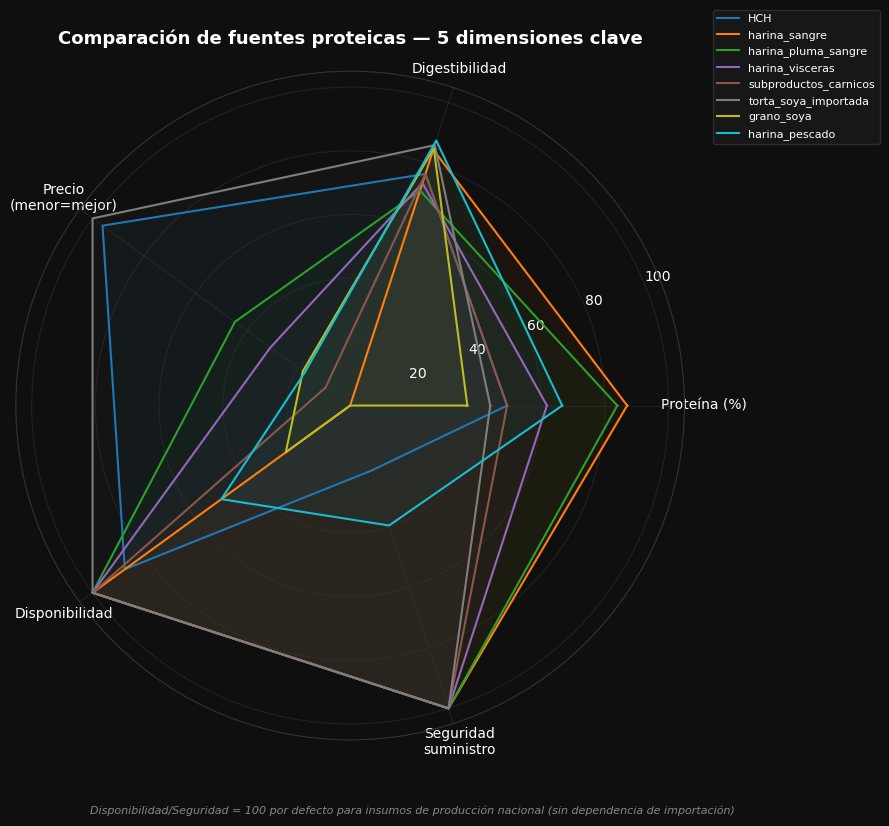

In [237]:
proteicos = ['HCH', 'harina_sangre', 'harina_pluma_sangre', 'harina_visceras',
             'subproductos_carnicos', 'torta_soya_importada', 'grano_soya', 'harina_pescado']
df_prot = df_ing[df_ing['insumo'].isin(proteicos)].copy()

df_prot['precio_final'] = df_prot['precio_usd_ton_bmc'].fillna(df_prot['precio_usd_ton_comtrade'])
df_prot['digest_prom'] = (df_prot['Digestibilidad Porcino (%)'] + df_prot['Digestibilidad Aves (%)']) / 2
df_prot['disponibilidad_score'] = df_prot['n_paises_proveedores'].fillna(8) / 8 * 100
df_prot['seguridad_score'] = 100 - df_prot['pct_concentracion_top_pais'].fillna(0)

pmin, pmax = df_prot['precio_final'].min(), df_prot['precio_final'].max()
df_prot['precio_score'] = 100 - ((df_prot['precio_final'] - pmin) / (pmax - pmin) * 100)

dims = ['Proteina bruta (%)', 'digest_prom', 'precio_score', 'disponibilidad_score', 'seguridad_score']
labels = ['Proteína (%)', 'Digestibilidad', 'Precio\n(menor=mejor)', 'Disponibilidad', 'Seguridad\nsuministro']

angles = np.linspace(0, 2*np.pi, len(dims), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')

colors = plt.cm.tab10(np.linspace(0, 1, len(df_prot)))

for i, (_, row) in enumerate(df_prot.iterrows()):
    valores = [row[d] for d in dims]
    valores += valores[:1]
    ax.plot(angles, valores, linewidth=1.5, label=row['insumo'], color=colors[i])
    ax.fill(angles, valores, alpha=0.05, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, color='white')
ax.tick_params(colors='white')
ax.spines['polar'].set_color('#333')
ax.grid(color='#333', alpha=0.5)

ax.set_title('Comparación de fuentes proteicas — 5 dimensiones clave', 
              color='white', size=13, weight='bold', pad=20)
legend = ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8, 
                    facecolor='#1a1a1a', edgecolor='#333')
for text in legend.get_texts():
    text.set_color('white')

fig.text(0.1, 0.02, 'Disponibilidad/Seguridad = 100 por defecto para insumos de producción nacional (sin dependencia de importación)',
          fontsize=8, style='italic', color='#888')

plt.tight_layout()
plt.show()

Los insumos de producción nacional (BMC) reciben disponibilidad y seguridad de 
suministro = 100 por defecto, al no depender de importación. Esto simplifica la 
comparación, pero no evalúa riesgo de concentración dentro del mercado nacional 
(ej. número de mataderos, regiones productoras) — sería una extensión futura 
del análisis.

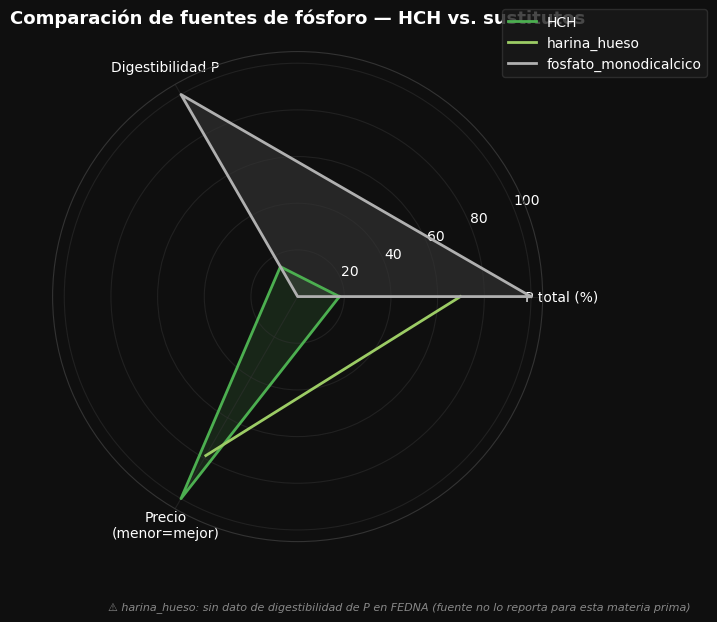

In [235]:
fosforo = ['HCH', 'harina_hueso', 'fosfato_monodicalcico']
df_p = df_ing[df_ing['insumo'].isin(fosforo)].copy()

df_p['precio_final'] = df_p['precio_usd_ton_bmc'].fillna(df_p['precio_usd_ton_comtrade'])
pmin, pmax = df_p['precio_final'].min(), df_p['precio_final'].max()
df_p['precio_score'] = 100 - ((df_p['precio_final'] - pmin) / (pmax - pmin) * 100) if pmax > pmin else 100
df_p['P_total_norm'] = df_p['P total (%)'] / df_p['P total (%)'].max() * 100
df_p['Pdig_prom'] = (df_p['Pdig Porcino (%)'] + df_p['Pdig Aves (%)']) / 2
df_p['Pdig_norm'] = df_p['Pdig_prom'] / df_p['Pdig_prom'].max() * 100

dims_p = ['P_total_norm', 'Pdig_norm', 'precio_score']
labels_p = ['P total (%)', 'Digestibilidad P', 'Precio\n(menor=mejor)']

angles_p = np.linspace(0, 2*np.pi, len(dims_p), endpoint=False).tolist()
angles_p += angles_p[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')

colors_p = ['#4CAF50', '#9CCC65', '#B0B0B0']  # verde HCH, verde claro harina_hueso, gris fosfato

for i, (_, row) in enumerate(df_p.iterrows()):
    valores = [row[d] for d in dims_p]
    valores += valores[:1]
    ax.plot(angles_p, valores, linewidth=2, label=row['insumo'], color=colors_p[i])
    ax.fill(angles_p, valores, alpha=0.15, color=colors_p[i])

ax.set_xticks(angles_p[:-1])
ax.set_xticklabels(labels_p, color='white')
ax.tick_params(colors='white')
ax.spines['polar'].set_color('#333')
ax.grid(color='#333', alpha=0.5)

ax.set_title('Comparación de fuentes de fósforo — HCH vs. sustitutos', 
              color='white', fontsize=13, fontweight='bold', pad=20)
legend = ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), facecolor='#1a1a1a', edgecolor='#333')
for text in legend.get_texts():
    text.set_color('white')

fig.text(0.1, 0.02, '⚠️ harina_hueso: sin dato de digestibilidad de P en FEDNA (fuente no lo reporta para esta materia prima)',
          fontsize=8, style='italic', color='#888')

plt.tight_layout()
plt.show()

Fosfato_monodicálcico domina claramente en concentración de fósforo 
(21.5% P total, frente a solo 3.85% de HCH y 15% de harina_hueso), y es el más caro de 
los tres. HCH y harina_hueso son visualmente casi indistinguibles en este radar — 
ambos son fuentes de P mucho menos concentradas que el fosfato mineral, pero también 
notablemente más baratas por tonelada.

Esto tiene una implicación práctica clara para el Análisis 2.c: en términos de 
**concentración pura**, fosfato_monodicálcico es la fuente más eficiente (se necesita 
menos cantidad de producto para aportar la misma cantidad de P a la ración). Sin 
embargo, HCH aporta P **como subproducto de su función principal** (proteína), por 
lo que su "costo marginal" de fósforo es distinto al de comprar fosfato como 
insumo dedicado — un formulador que ya está usando HCH por proteína obtiene el 
fósforo "gratis" adicional, mientras que quien usa fosfato_monodicálcico paga 
específicamente por esa función.

**Dato pendiente:** no se cuenta con digestibilidad de P para harina_hueso (FEDNA 
no reporta ese valor para esta materia prima) — esto limita la comparación completa 
en ese eje para ese insumo específicamente.

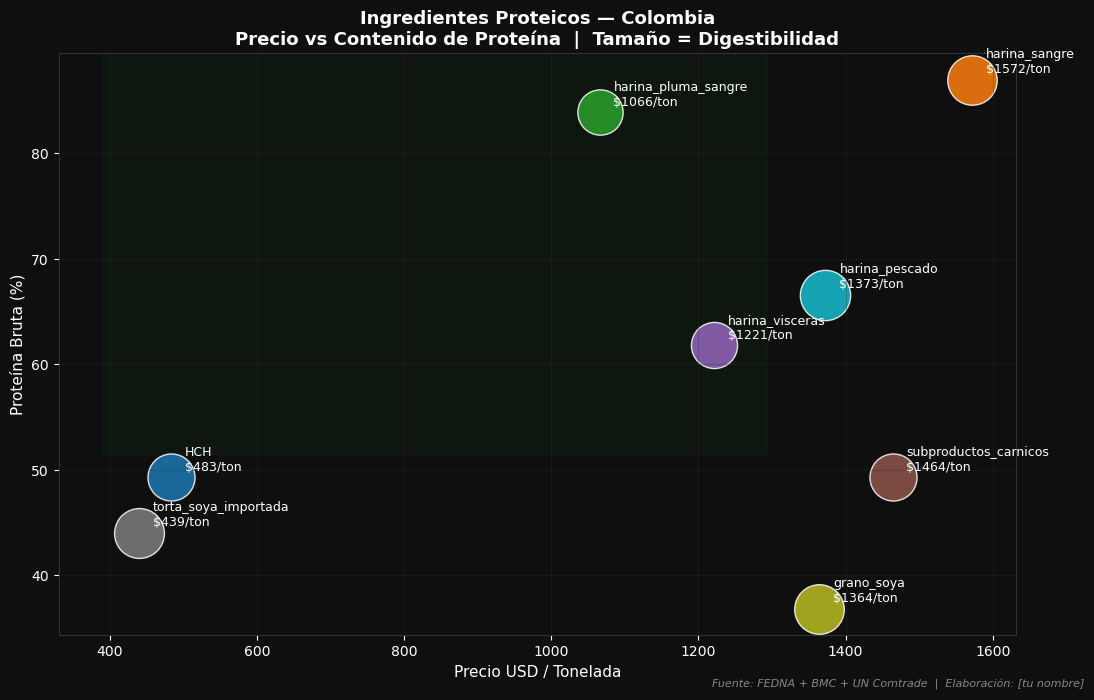

In [233]:
import matplotlib.pyplot as plt
import numpy as np

proteicos = ['HCH', 'harina_sangre', 'harina_pluma_sangre', 'harina_visceras',
             'subproductos_carnicos', 'torta_soya_importada', 'grano_soya', 'harina_pescado']
df_bubble = df_ing[df_ing['insumo'].isin(proteicos)].copy()
df_bubble['precio_final'] = df_bubble['precio_usd_ton_bmc'].fillna(df_bubble['precio_usd_ton_comtrade'])
df_bubble['digest_prom'] = (df_bubble['Digestibilidad Porcino (%)'] + df_bubble['Digestibilidad Aves (%)']) / 2

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')

colores = plt.cm.tab10(np.linspace(0, 1, len(df_bubble)))

# Zona ideal: barato + proteína alta (cuadrante superior izquierdo)
precio_medio = df_bubble['precio_final'].median()
proteina_media = df_bubble['Proteina bruta (%)'].median()
ax.axvspan(df_bubble['precio_final'].min()-50, precio_medio, 
           ymin=(proteina_media - df_bubble['Proteina bruta (%)'].min()) / (df_bubble['Proteina bruta (%)'].max() - df_bubble['Proteina bruta (%)'].min() + 10),
           color='green', alpha=0.08)

for i, (_, row) in enumerate(df_bubble.iterrows()):
    size = row['digest_prom'] * 15  # escala visual del tamaño
    ax.scatter(row['precio_final'], row['Proteina bruta (%)'], s=size, 
               color=colores[i], alpha=0.85, edgecolors='white', linewidth=1)
    ax.annotate(f"{row['insumo']}\n${row['precio_final']:.0f}/ton", 
                (row['precio_final'], row['Proteina bruta (%)']),
                xytext=(10, 5), textcoords='offset points', color='white', fontsize=9)

ax.set_xlabel('Precio USD / Tonelada', color='white', fontsize=11)
ax.set_ylabel('Proteína Bruta (%)', color='white', fontsize=11)
ax.set_title('Ingredientes Proteicos — Colombia\nPrecio vs Contenido de Proteína  |  Tamaño = Digestibilidad', 
              color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.grid(True, color='#333', alpha=0.3)

fig.text(0.99, 0.01, 'Fuente: FEDNA + BMC + UN Comtrade  |  Elaboración: [tu nombre]',
         ha='right', fontsize=8, color='#888', style='italic')

plt.tight_layout()
plt.show()

**Interpretación:** El bubble chart confirma un trade-off claro entre precio y contenido 
proteico entre los 8 insumos analizados. HCH ($483/ton, 49% proteína) se ubica entre 
los más económicos del grupo, junto con torta_soya_importada ($439/ton, 44%) — ambos 
en el rango de precio más bajo, pero también con proteína moderada frente al resto.

En el extremo opuesto, harina_sangre ($1,572/ton, 87%) y harina_pluma_sangre 
($1,066/ton, 84%) concentran la proteína más alta del mercado, a un costo entre 
2 y 3 veces superior al de HCH.

Ningún insumo cae en el "cuadrante ideal" (barato + proteína alta) — el mercado 
refleja un trade-off consistente: a mayor contenido proteico, mayor precio. Esto 
posiciona a HCH como una opción de **entrada económica** en la formulación (costo 
bajo, proteína aceptable), más que como fuente de proteína concentrada — un rol 
distinto al de harina_sangre o harina_pluma_sangre, que servirían para "reforzar" 
proteína en dietas que ya usan una base más económica como HCH.

El tamaño de burbuja (digestibilidad) no muestra un patrón claro asociado al precio 
o a la proteína — insumos de precio medio como harina_visceras y harina_pescado 
tienen digestibilidades competitivas (73-88%), similares a las de insumos mucho 
más caros, lo que sugiere que la digestibilidad es una dimensión relativamente 
independiente del costo en este grupo.

## F6. Sacrificio bovino

### 1.1 Entendimiento por tabla - Sacrificio bovino

In [245]:
import sqlite3, pandas as pd

DB_PATH = "mercado_hch.db"
def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

n = query("SELECT COUNT(*) AS n FROM sacrificio_bovino")['n'].iloc[0]
print(f"📊 sacrificio_bovino: {n} filas")
print(query("PRAGMA table_info(sacrificio_bovino)").to_string(index=False))
print()
print("Primeras 3 filas:")
print(query("SELECT * FROM sacrificio_bovino ORDER BY fecha LIMIT 3").to_string(index=False))
print("\nÚltimas 3 filas:")
print(query("SELECT * FROM sacrificio_bovino ORDER BY fecha DESC LIMIT 3").to_string(index=False))

📊 sacrificio_bovino: 210 filas
 cid              name      type  notnull dflt_value  pk
   0             fecha TIMESTAMP        0       None   0
   1   vacunos_cabezas      REAL        0       None   0
   2 bufalinos_cabezas      REAL        0       None   0
   3     potencial_hch      REAL        0       None   0
   4            fuente      TEXT        0       None   0

Primeras 3 filas:
              fecha  vacunos_cabezas  bufalinos_cabezas  potencial_hch    fuente
2008-10-01 00:00:00         369016.0                6.0       369022.0 DANE_ESAG
2008-11-01 00:00:00         350067.0               71.0       350138.0 DANE_ESAG
2008-12-01 00:00:00         365661.0              225.0       365886.0 DANE_ESAG

Últimas 3 filas:
              fecha  vacunos_cabezas  bufalinos_cabezas  potencial_hch    fuente
2026-03-01 00:00:00         289616.0             5314.0       294930.0 DANE_ESAG
2026-02-01 00:00:00         270673.0             5031.0       275704.0 DANE_ESAG
2026-01-01 00:00:00    

Cada fila es el número de cabezas de ganado (vacuno + bufalino) sacrificadas en Colombia en un mes calendario específico, según la Encuesta de Sacrificio de Ganado (ESAG) del DANE. Es un proxy de la oferta local de materia prima disponible para producir HCH — a más sacrificio, más subproductos cárnicos disponibles para convertir en harina.

### 1.2 Reglas del negocio - Sacrificio bovino

In [248]:
df_sac = query("SELECT * FROM sacrificio_bovino")

print("="*60)
print("REGLA 1 — Consistencia: potencial_hch = vacunos + bufalinos")
print("="*60)
df_sac['calculado'] = df_sac['vacunos_cabezas'].fillna(0) + df_sac['bufalinos_cabezas'].fillna(0)
inconsistentes = df_sac[df_sac['potencial_hch'] != df_sac['calculado']]
print(f"Filas evaluadas: {len(df_sac)}")
print(f"Inconsistentes: {len(inconsistentes)}")

print("\n" + "="*60)
print("REGLA 2 — Valores positivos (no negativos ni cero)")
print("="*60)
invalidos = df_sac[(df_sac['vacunos_cabezas'] <= 0) | (df_sac['potencial_hch'] <= 0)]
print(f"Filas con valores ≤0: {len(invalidos)}")

print("\n" + "="*60)
print("REGLA 3 — Continuidad mensual (sin huecos en la serie)")
print("="*60)
df_sac['fecha'] = pd.to_datetime(df_sac['fecha'])
df_sac = df_sac.sort_values('fecha')
rango_esperado = pd.date_range(df_sac['fecha'].min(), df_sac['fecha'].max(), freq='MS')
faltantes = set(rango_esperado) - set(df_sac['fecha'])
print(f"Meses esperados: {len(rango_esperado)} | Meses presentes: {len(df_sac)} | Meses faltantes: {len(faltantes)}")
if faltantes:
    print(sorted(faltantes)[:10])

print("\n" + "="*60)
print("REGLA 4 — Fechas en rango razonable")
print("="*60)
hoy = pd.Timestamp.today()
fuera_rango = df_sac[(df_sac['fecha'] > hoy) | (df_sac['fecha'] < '2000-01-01')]
print(f"Filas fuera de rango: {len(fuera_rango)}")

REGLA 1 — Consistencia: potencial_hch = vacunos + bufalinos
Filas evaluadas: 210
Inconsistentes: 0

REGLA 2 — Valores positivos (no negativos ni cero)
Filas con valores ≤0: 0

REGLA 3 — Continuidad mensual (sin huecos en la serie)
Meses esperados: 210 | Meses presentes: 210 | Meses faltantes: 0

REGLA 4 — Fechas en rango razonable
Filas fuera de rango: 0


### 1.3 Análisis descriptivo - Sacrificio bovino

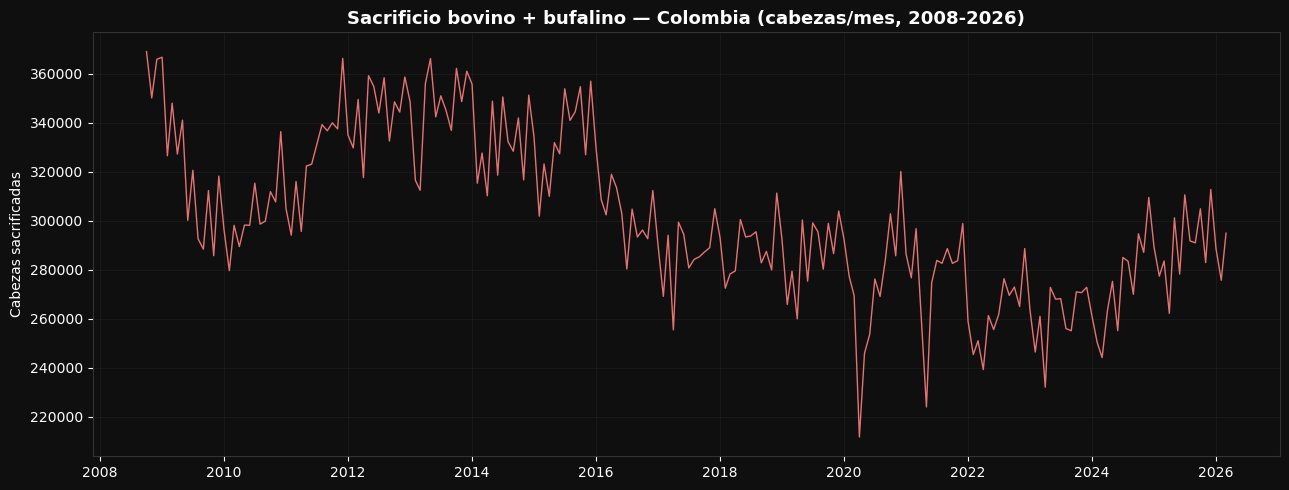

Mínimo: 211727 | Máximo: 369022
Promedio: 301240


In [257]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

con = sqlite3.connect(DB_PATH)
df_sac = pd.read_sql("SELECT fecha, potencial_hch FROM sacrificio_bovino ORDER BY fecha", con)
con.close()

df_sac['fecha'] = pd.to_datetime(df_sac['fecha'])

fig, ax = plt.subplots(figsize=(13,5))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')
ax.plot(df_sac['fecha'], df_sac['potencial_hch'], color='#E57373', linewidth=1)
ax.set_title('Sacrificio bovino + bufalino — Colombia (cabezas/mes, 2008-2026)', 
              color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('Cabezas sacrificadas', color='white')
ax.tick_params(colors='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.grid(True, color='#333', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mínimo: {df_sac['potencial_hch'].min():.0f} | Máximo: {df_sac['potencial_hch'].max():.0f}")
print(f"Promedio: {df_sac['potencial_hch'].mean():.0f}")

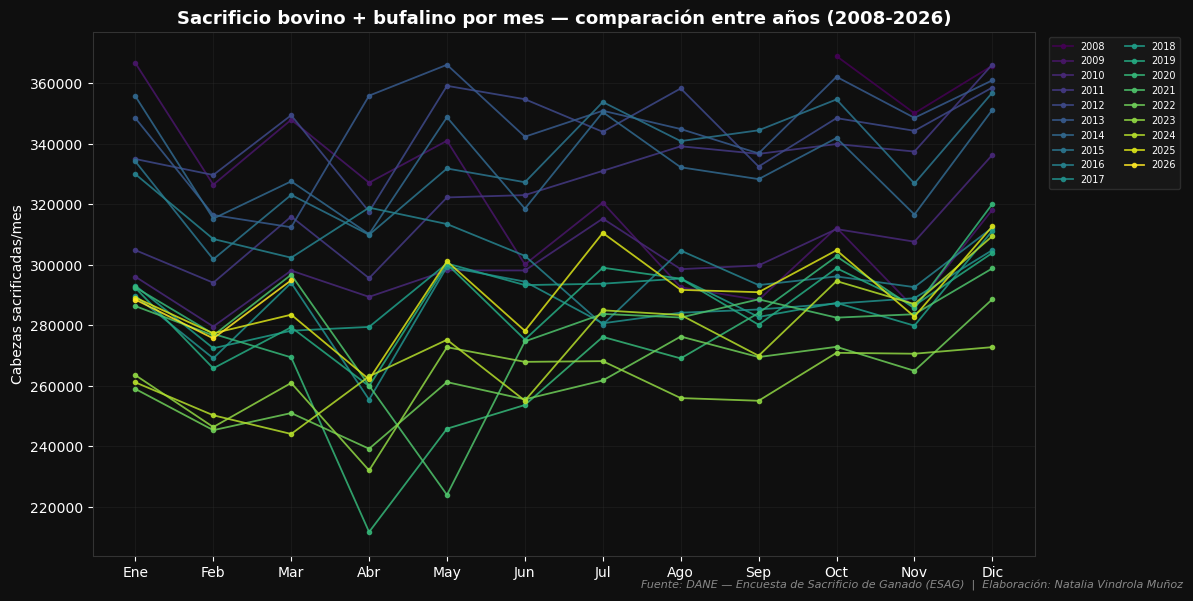

In [265]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

con = sqlite3.connect(DB_PATH)
df_sac = pd.read_sql("SELECT fecha, potencial_hch FROM sacrificio_bovino ORDER BY fecha", con)
con.close()

df_sac['fecha'] = pd.to_datetime(df_sac['fecha'])
df_sac['anio'] = df_sac['fecha'].dt.year
df_sac['mes'] = df_sac['fecha'].dt.month

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')

anios = sorted(df_sac['anio'].unique())
colores = cm.viridis(np.linspace(0, 1, len(anios)))

for i, anio in enumerate(anios):
    sub = df_sac[df_sac['anio'] == anio].sort_values('mes')
    ax.plot(sub['mes'], sub['potencial_hch'], marker='o', markersize=3,
            color=colores[i], linewidth=1.3, alpha=0.85, label=str(anio))

meses_nombre = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombre, color='white')
ax.set_ylabel('Cabezas sacrificadas/mes', color='white')
ax.set_title('Sacrificio bovino + bufalino por mes — comparación entre años (2008-2026)', 
              color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.grid(True, color='#333', alpha=0.3)

legend = ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7,
                    ncol=2, facecolor='#1a1a1a', edgecolor='#333')
for text in legend.get_texts():
    text.set_color('white')

fig.text(0.99, 0.01, 'Fuente: DANE — Encuesta de Sacrificio de Ganado (ESAG)  |  Elaboración: Natalia Vindrola Muñoz',
          ha='right', fontsize=8, color='#888', style='italic')

plt.tight_layout()
plt.show()

C:\Users\nvind\AppData\Local\Temp\ipykernel_33260\3610587027.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_por_mes, labels=meses_nombre, patch_artist=True)


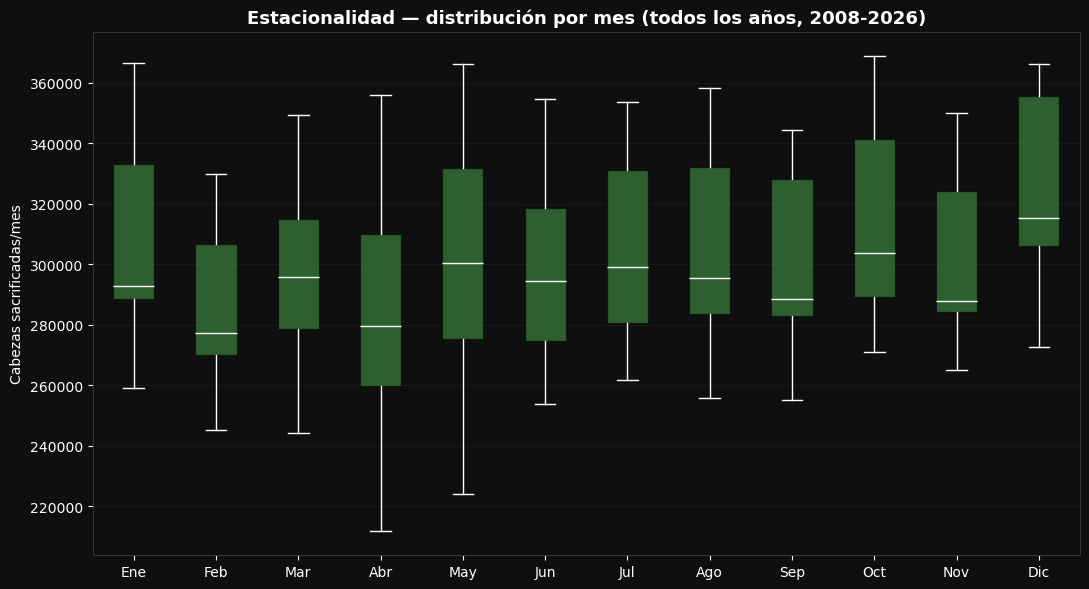

In [267]:
fig, ax = plt.subplots(figsize=(11,6))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')

datos_por_mes = [df_sac[df_sac['mes']==m]['potencial_hch'].values for m in range(1,13)]
bp = ax.boxplot(datos_por_mes, labels=meses_nombre, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('#4CAF50')
    patch.set_alpha(0.5)
for element in ['whiskers','caps','medians']:
    plt.setp(bp[element], color='white')
for flier in bp['fliers']:
    flier.set(marker='o', color='#E57373', alpha=0.5)

ax.set_ylabel('Cabezas sacrificadas/mes', color='white')
ax.set_title('Estacionalidad — distribución por mes (todos los años, 2008-2026)', 
              color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.grid(True, axis='y', color='#333', alpha=0.3)
plt.tight_layout()
plt.show()

1.3 Análisis descriptivo

**Tendencia de largo plazo — descenso estructural:** el volumen de sacrificio bovino 
+ bufalino ha disminuido de forma sostenida a lo largo de casi dos décadas — de un 
rango de ~330,000–370,000 cabezas/mes en el período 2008-2013, a ~250,000–310,000 
cabezas/mes en 2022-2026. Esto reduce progresivamente la oferta de materia prima 
local para HCH, y es un factor relevante para explicar presiones de precio al alza 
que no se justifican únicamente por TRM o por el precio de sustitutos importados.

**Estacionalidad confirmada:** a diferencia de HCH (que no mostró un patrón estacional 
claro en su análisis descriptivo), el sacrificio bovino sí presenta un ciclo mensual 
repetible, consistente año tras año:

- **Febrero** es sistemáticamente el mes de menor sacrificio (mediana más baja de 
  todo el año, con dispersión relativamente estrecha entre años).
- **Diciembre** es el mes de mayor sacrificio (mediana más alta), aunque también el 
  de mayor variabilidad entre años.
- **Abril** es el mes más incierto: su mediana es normal/baja, pero registra el 
  mínimo histórico absoluto de toda la serie (~212,000 cabezas), lo que sugiere que 
  en al menos un año hubo un choque puntual (posible sequía, cierre de fronteras, 
  paro, o evento sanitario) más que un patrón estructural repetido cada año.

**Implicación para el modelo:** dado que sacrificio bovino sí tiene estacionalidad 
real y HCH no, vale la pena que el modelo de predicción (Analítica 2.0) capture esta 
variable con su propio ciclo mensual, en vez de asumir que el mes del año no aporta 
señal — como sí se descartó para HCH directamente.

## F7 (RONI)

### 1.1 Entendimiento por tabla - F7 (RONI)

In [275]:
import sqlite3, pandas as pd

DB_PATH = "mercado_hch.db"
def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

n = query("SELECT COUNT(*) AS n FROM roni_mensual")['n'].iloc[0]
print(f"📊 roni_mensual: {n} filas")
print(query("PRAGMA table_info(roni_mensual)").to_string(index=False))
print()
print("Primeras 5 filas:")
print(query("SELECT * FROM roni_mensual ORDER BY anio_mes LIMIT 5").to_string(index=False))
print("\nÚltimas 5 filas:")
print(query("SELECT * FROM roni_mensual ORDER BY anio_mes DESC LIMIT 5").to_string(index=False))

📊 roni_mensual: 917 filas
 cid     name type  notnull dflt_value  pk
   0 anio_mes TEXT        0       None   0
   1     roni REAL        0       None   0

Primeras 5 filas:
anio_mes  roni
 1950-01 -1.47
 1950-02 -1.27
 1950-03 -1.11
 1950-04 -1.09
 1950-05 -1.00

Últimas 5 filas:
anio_mes  roni
 2026-05  0.47
 2026-04 -0.04
 2026-03 -0.45
 2026-02 -0.71
 2026-01 -0.88


Cada fila es el valor del índice RONI (Relative Oceanic Niño Index) para un mes específico — un indicador climático oficial de NOAA que mide la anomalía de temperatura superficial del océano Pacífico ecuatorial, usado para identificar fases de El Niño (valores positivos) y La Niña (valores negativos). Se incluye en el proyecto como variable predictora indirecta: estos fenómenos climáticos afectan sequías/lluvias en Colombia, que a su vez impactan el sacrificio bovino (F6) y las cosechas de maíz/soya (F2) — con un rezago de varios meses, por eso también calculaste roni_lag3 y roni_lag6

### 1.2 Reglas de negocio - F7 (RONI)

In [278]:
df_roni = query("SELECT * FROM roni_mensual")

print("="*60)
print("REGLA 1 — Rango físicamente plausible del índice (-4 a +4)")
print("="*60)
# El RONI/ONI histórico global oscila típicamente entre -3 y +3, con extremos raros hasta ±4
fuera_rango = df_roni[(df_roni['roni'] < -4) | (df_roni['roni'] > 4)]
print(f"Filas fuera de rango: {len(fuera_rango)}")

print("\n" + "="*60)
print("REGLA 2 — Formato de anio_mes válido (YYYY-MM)")
print("="*60)
import re
patron_valido = df_roni['anio_mes'].str.match(r'^\d{4}-\d{2}$')
print(f"Filas con formato inválido: {(~patron_valido).sum()}")

print("\n" + "="*60)
print("REGLA 3 — Continuidad mensual (sin huecos)")
print("="*60)
fechas = pd.to_datetime(df_roni['anio_mes'], format='%Y-%m').sort_values()
rango_esperado = pd.date_range(fechas.min(), fechas.max(), freq='MS')
faltantes = set(rango_esperado) - set(fechas)
print(f"Meses esperados: {len(rango_esperado)} | Presentes: {len(df_roni)} | Faltantes: {len(faltantes)}")
if faltantes:
    print(sorted(faltantes)[:10])

print("\n" + "="*60)
print("REGLA 4 — Sin duplicados de anio_mes")
print("="*60)
dup = df_roni['anio_mes'].duplicated().sum()
print(f"Filas duplicadas: {dup}")

REGLA 1 — Rango físicamente plausible del índice (-4 a +4)
Filas fuera de rango: 0

REGLA 2 — Formato de anio_mes válido (YYYY-MM)
Filas con formato inválido: 0

REGLA 3 — Continuidad mensual (sin huecos)
Meses esperados: 917 | Presentes: 917 | Faltantes: 0

REGLA 4 — Sin duplicados de anio_mes
Filas duplicadas: 0


### 1.3 Análisis descrip´tivo - F7 (RONI)

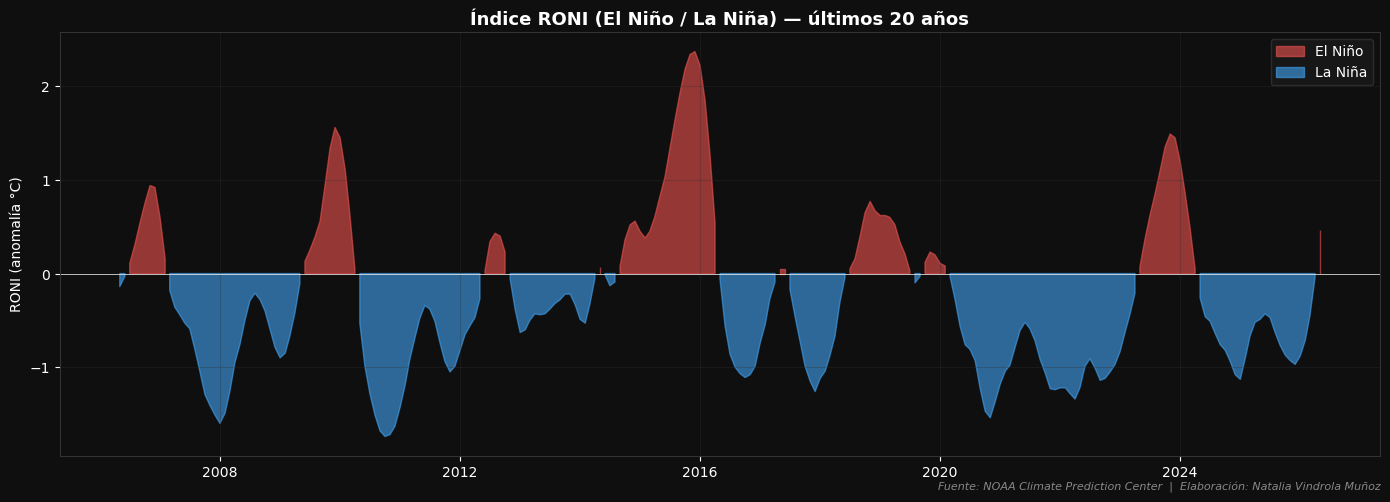

In [286]:
import matplotlib.pyplot as plt
import pandas as pd

con = sqlite3.connect(DB_PATH)
df_roni = pd.read_sql("SELECT * FROM roni_mensual ORDER BY anio_mes", con)
con.close()

df_roni['fecha'] = pd.to_datetime(df_roni['anio_mes'], format='%Y-%m')

# ── Filtro: últimos 20 años ──
fecha_max = df_roni['fecha'].max()
fecha_min_20 = fecha_max - pd.DateOffset(years=20)
df_roni_20 = df_roni[df_roni['fecha'] >= fecha_min_20]

fig, ax = plt.subplots(figsize=(14,5))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')

ax.fill_between(df_roni_20['fecha'], df_roni_20['roni'], 0, 
                 where=(df_roni_20['roni'] >= 0), color='#EF5350', alpha=0.6, label='El Niño')
ax.fill_between(df_roni_20['fecha'], df_roni_20['roni'], 0, 
                 where=(df_roni_20['roni'] < 0), color='#42A5F5', alpha=0.6, label='La Niña')
ax.axhline(0, color='white', linewidth=0.5)

ax.set_title('Índice RONI (El Niño / La Niña) — últimos 20 años', color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('RONI (anomalía °C)', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.grid(True, color='#333', alpha=0.3)
legend = ax.legend(facecolor='#1a1a1a', edgecolor='#333')
for text in legend.get_texts():
    text.set_color('white')

fig.text(0.99, 0.01, 'Fuente: NOAA Climate Prediction Center  |  Elaboración: Natalia Vindrola Muñoz',
          ha='right', fontsize=8, color='#888', style='italic')

plt.tight_layout()
plt.show()

## F8. Demanda porcina (sacrificio porcino — DANE ESAG)

### 1.1 Entendimiento por tabla - F8 Sacrificio porcino

In [5]:
n = query("SELECT COUNT(*) AS n FROM sacrificio_bovino WHERE porcinos_cabezas IS NOT NULL")['n'].iloc[0]
print(f"📊 porcinos_cabezas (en sacrificio_bovino): {n} filas con dato")
print(query("PRAGMA table_info(sacrificio_bovino)").to_string(index=False))
print()
print("Primeras 3 filas:")
print(query("SELECT fecha, porcinos_cabezas FROM sacrificio_bovino ORDER BY fecha LIMIT 3").to_string(index=False))
print("\nÚltimas 3 filas:")
print(query("SELECT fecha, porcinos_cabezas FROM sacrificio_bovino ORDER BY fecha DESC LIMIT 3").to_string(index=False))

📊 porcinos_cabezas (en sacrificio_bovino): 210 filas con dato
 cid              name      type  notnull dflt_value  pk
   0             fecha TIMESTAMP        0       None   0
   1   vacunos_cabezas      REAL        0       None   0
   2 bufalinos_cabezas      REAL        0       None   0
   3     potencial_hch      REAL        0       None   0
   4            fuente      TEXT        0       None   0
   5  porcinos_cabezas      REAL        0       None   0

Primeras 3 filas:
              fecha  porcinos_cabezas
2008-10-01 00:00:00          185739.0
2008-11-01 00:00:00          168379.0
2008-12-01 00:00:00          231031.0

Últimas 3 filas:
              fecha  porcinos_cabezas
2026-03-01 00:00:00          593273.0
2026-02-01 00:00:00          538695.0
2026-01-01 00:00:00          566027.0


Fila = un mes calendario con el número de cabezas de cerdo sacrificadas a nivel nacional (DANE-ESAG, 'Cuadro 3'). Vive en la misma tabla que vacunos/bufalinos porque comparten fuente y grano (mensual), pero es un indicador de **demanda** (consumo potencial de concentrado), no de oferta de HCH.

## 1.2 Reglas de negocio - F8 Sacrificio porcino

In [8]:
df_porc = query("SELECT fecha, porcinos_cabezas FROM sacrificio_bovino WHERE porcinos_cabezas IS NOT NULL")
df_porc['fecha'] = pd.to_datetime(df_porc['fecha'])
df_porc = df_porc.sort_values('fecha')

print("="*60)
print("REGLA 1 — Valores positivos (no negativos ni cero)")
print("="*60)
invalidos = df_porc[df_porc['porcinos_cabezas'] <= 0]
print(f"Filas con valores ≤0: {len(invalidos)}")

print("\n" + "="*60)
print("REGLA 2 — Continuidad mensual (sin huecos en la serie)")
print("="*60)
rango_esperado = pd.date_range(df_porc['fecha'].min(), df_porc['fecha'].max(), freq='MS')
faltantes = set(rango_esperado) - set(df_porc['fecha'])
print(f"Meses esperados: {len(rango_esperado)} | Meses presentes: {len(df_porc)} | Meses faltantes: {len(faltantes)}")
if faltantes:
    print(sorted(faltantes)[:10])

print("\n" + "="*60)
print("REGLA 3 — Fechas en rango razonable")
print("="*60)
hoy = pd.Timestamp.today()
fuera_rango = df_porc[(df_porc['fecha'] > hoy) | (df_porc['fecha'] < '2000-01-01')]
print(f"Filas fuera de rango: {len(fuera_rango)}")

print("\n" + "="*60)
print("REGLA 4 — Consistencia de escala vs. vacunos_cabezas")
print("="*60)
df_comp = query("SELECT fecha, vacunos_cabezas, porcinos_cabezas FROM sacrificio_bovino WHERE porcinos_cabezas IS NOT NULL")
df_comp['ratio'] = df_comp['porcinos_cabezas'] / df_comp['vacunos_cabezas']
print(f"Ratio porcinos/vacunos — min: {df_comp['ratio'].min():.2f}, max: {df_comp['ratio'].max():.2f}, promedio: {df_comp['ratio'].mean():.2f}")
print("(Un salto brusco en el ratio mes a mes sería señal de dato mal capturado)")

REGLA 1 — Valores positivos (no negativos ni cero)
Filas con valores ≤0: 0

REGLA 2 — Continuidad mensual (sin huecos en la serie)
Meses esperados: 210 | Meses presentes: 210 | Meses faltantes: 0

REGLA 3 — Fechas en rango razonable
Filas fuera de rango: 0

REGLA 4 — Consistencia de escala vs. vacunos_cabezas
Ratio porcinos/vacunos — min: 0.42, max: 2.27, promedio: 1.23
(Un salto brusco en el ratio mes a mes sería señal de dato mal capturado)


## 1.3 Análisis descriptivo - F8 Sacrificio porcino

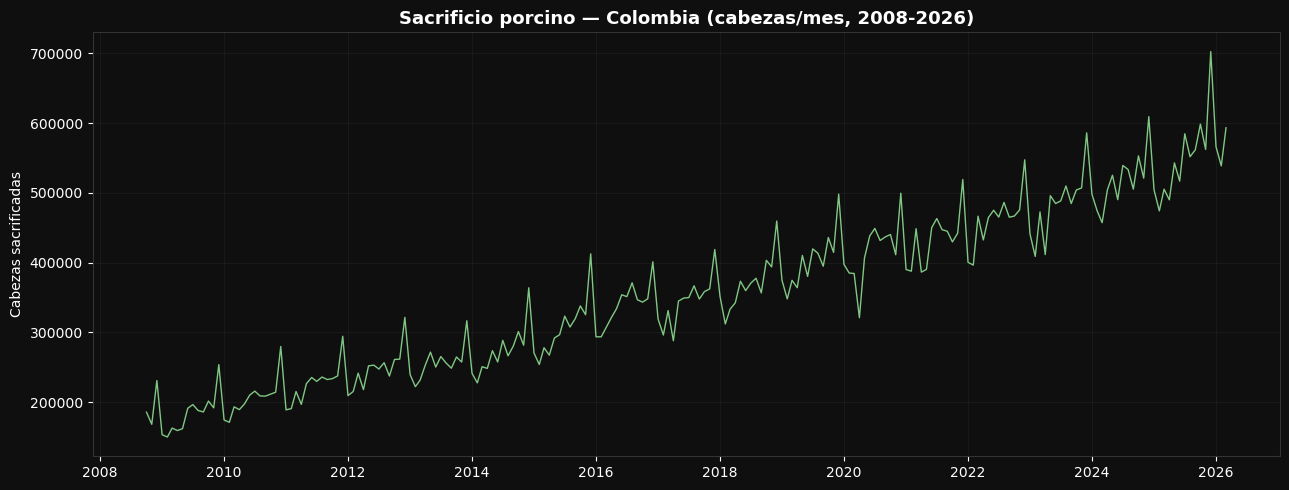

Mínimo: 150172 | Máximo: 702414
Promedio: 354799


In [15]:
fig, ax = plt.subplots(figsize=(13,5))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')
ax.plot(df_porc['fecha'], df_porc['porcinos_cabezas'], color='#81C784', linewidth=1)
ax.set_title('Sacrificio porcino — Colombia (cabezas/mes, 2008-2026)',
              color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('Cabezas sacrificadas', color='white')
ax.tick_params(colors='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.grid(True, color='#333', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mínimo: {df_porc['porcinos_cabezas'].min():.0f} | Máximo: {df_porc['porcinos_cabezas'].max():.0f}")
print(f"Promedio: {df_porc['porcinos_cabezas'].mean():.0f}")

## F9. Demanda concentrados terminado (BMC) — avícola, porcino, mascotas

### 1.1 Entendimiento por tabla - F9. Demanda concentrados terminado

In [10]:
import sqlite3
import pandas as pd

DB_PATH = "mercado_hch.db"

with sqlite3.connect(DB_PATH) as con:
    resultado = pd.read_sql("""
        SELECT producto, COUNT(*) AS filas, MIN(fecha) AS desde, MAX(fecha) AS hasta,
               ROUND(SUM(cantidad_kg)/1000, 1) AS ton_total
        FROM bmc_precios_limpio
        WHERE producto LIKE '%perro%' OR producto LIKE '%gato%' OR producto LIKE '%mascota%' OR producto LIKE '%concentrado%'
        GROUP BY producto
    """, con)

print(resultado)

             producto  filas       desde       hasta  ton_total
0    concentrado_aves    648  2022-09-12  2026-05-26  4648204.6
1  concentrado_cerdos    666  2022-09-12  2026-05-27  3361183.5
2   concentrado_gatos    780  2022-09-12  2026-05-29   157827.6
3  concentrado_perros    717  2022-09-12  2026-05-29   492306.4


### 1.2 Reglas de negocio - F9. Demanda concentrados terminado

In [14]:
import sqlite3, pandas as pd

DB_PATH = "mercado_hch.db"
def query(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

productos_demanda = {
    'demanda_concentrado_avicola': 'concentrado_aves',
    'demanda_concentrado_porcino': 'concentrado_cerdos',
    'demanda_concentrado_perros':  'concentrado_perros',
    'demanda_concentrado_gatos':   'concentrado_gatos',
}

resumen_f9 = []
for codigo, producto in productos_demanda.items():
    df = query("SELECT fecha, cantidad_kg FROM bmc_precios_limpio WHERE producto = ?", [producto])
    df['fecha'] = pd.to_datetime(df['fecha'])

    print("="*70)
    print(f"{codigo}  (producto BMC: {producto})")
    print("="*70)
    print(f"Filas: {len(df)} | Rango: {df['fecha'].min().date()} → {df['fecha'].max().date()}")

    # Regla 1 — valores positivos
    invalidos = df[df['cantidad_kg'] <= 0]
    print(f"Regla 1 (valores >0): {len(invalidos)} inválidos")

    # Regla 2 — cobertura mensual tras agregar (¿algún mes sin ninguna rueda?)
    df['anio_mes'] = df['fecha'].dt.to_period('M')
    meses_presentes = df['anio_mes'].nunique()
    rango_meses = pd.period_range(df['anio_mes'].min(), df['anio_mes'].max(), freq='M')
    meses_faltantes = set(rango_meses) - set(df['anio_mes'])
    print(f"Regla 2 (cobertura mensual): {meses_presentes}/{len(rango_meses)} meses con al menos 1 rueda "
          f"| faltantes: {len(meses_faltantes)}")

    # Regla 3 — fechas en rango razonable
    hoy = pd.Timestamp.today()
    fuera_rango = df[(df['fecha'] > hoy) | (df['fecha'] < '2000-01-01')]
    print(f"Regla 3 (fechas en rango): {len(fuera_rango)} fuera de rango")

    # Regla 4 — outliers mes a mes tras agregar (para detectar rueda mal capturada)
    mensual = df.groupby('anio_mes')['cantidad_kg'].sum()
    variacion = mensual.pct_change().abs()
    saltos_grandes = variacion[variacion > 2.0]  # +200% de un mes a otro
    print(f"Regla 4 (saltos >200% mes a mes): {len(saltos_grandes)} casos")
    if len(saltos_grandes):
        print(saltos_grandes)

    resumen_f9.append({
        'indicador': codigo, 'producto_bmc': producto, 'filas': len(df),
        'meses_cubiertos': meses_presentes, 'meses_esperados': len(rango_meses),
        'ton_total': round(df['cantidad_kg'].sum()/1000, 1)
    })
    print()

print(pd.DataFrame(resumen_f9).to_string(index=False))

demanda_concentrado_avicola  (producto BMC: concentrado_aves)
Filas: 648 | Rango: 2022-09-12 → 2026-05-26
Regla 1 (valores >0): 0 inválidos
Regla 2 (cobertura mensual): 45/45 meses con al menos 1 rueda | faltantes: 0
Regla 3 (fechas en rango): 0 fuera de rango
Regla 4 (saltos >200% mes a mes): 1 casos
anio_mes
2026-01    2.201395
Freq: M, Name: cantidad_kg, dtype: float64

demanda_concentrado_porcino  (producto BMC: concentrado_cerdos)
Filas: 666 | Rango: 2022-09-12 → 2026-05-27
Regla 1 (valores >0): 0 inválidos
Regla 2 (cobertura mensual): 45/45 meses con al menos 1 rueda | faltantes: 0
Regla 3 (fechas en rango): 0 fuera de rango
Regla 4 (saltos >200% mes a mes): 2 casos
anio_mes
2024-01    4.141378
2026-01    4.772312
Freq: M, Name: cantidad_kg, dtype: float64

demanda_concentrado_perros  (producto BMC: concentrado_perros)
Filas: 717 | Rango: 2022-09-12 → 2026-05-29
Regla 1 (valores >0): 0 inválidos
Regla 2 (cobertura mensual): 45/45 meses con al menos 1 rueda | faltantes: 0
Regla 3 

### 1.3 Análisis descriptivo - F9. Demanda concentrados terminado

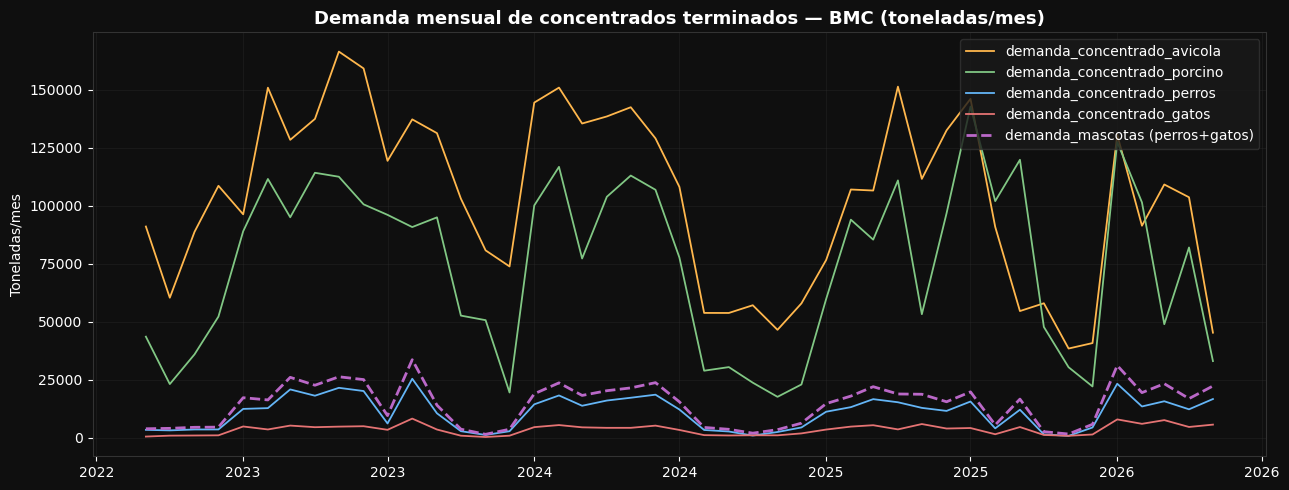

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(13,5))
fig.patch.set_facecolor('#0F0F0F'); ax.set_facecolor('#0F0F0F')
colores = {'demanda_concentrado_avicola': '#FFB74D', 'demanda_concentrado_porcino': '#81C784',
           'demanda_concentrado_perros': '#64B5F6', 'demanda_concentrado_gatos': '#E57373',
           'demanda_mascotas (perros+gatos)': '#BA68C8'}

series_mensuales = {}  # guardamos cada serie para poder sumarlas después

for codigo, producto in productos_demanda.items():
    df = query("SELECT fecha, cantidad_kg FROM bmc_precios_limpio WHERE producto = ?", [producto])
    df['fecha'] = pd.to_datetime(df['fecha'])
    mensual = df.set_index('fecha')['cantidad_kg'].resample('MS').sum() / 1000  # toneladas
    series_mensuales[codigo] = mensual
    ax.plot(mensual.index, mensual.values, label=codigo, color=colores[codigo], linewidth=1.3)

# ── Línea combinada: perros + gatos ──────────────────────────────
mascotas = series_mensuales['demanda_concentrado_perros'].add(
    series_mensuales['demanda_concentrado_gatos'], fill_value=0)
ax.plot(mascotas.index, mascotas.values, label='demanda_mascotas (perros+gatos)',
        color=colores['demanda_mascotas (perros+gatos)'], linewidth=2, linestyle='--')

ax.set_title('Demanda mensual de concentrados terminados — BMC (toneladas/mes)', color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('Toneladas/mes', color='white')
ax.tick_params(colors='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
for spine in ax.spines.values(): spine.set_edgecolor('#333')
ax.grid(True, color='#333', alpha=0.3)
legend = ax.legend(facecolor='#1a1a1a', edgecolor='#333')
for text in legend.get_texts(): text.set_color('white')
plt.tight_layout(); plt.show()

---
# ✅ Entregable 2 — Calidad de datos

Dimensiones: **Completitud · Unicidad · Validez · Consistencia · Exactitud · Oportunidad**
(las dos últimas se agregan específicamente porque los datos vienen de OCR + múltiples fuentes).

In [17]:
import sqlite3, pandas as pd

DB_PATH = "mercado_hch.db"
con = sqlite3.connect(DB_PATH)

resultados = []

# ── F1. TRM_diaria ──
df = pd.read_sql("SELECT * FROM trm_diaria", con)
resultados.append({
    'Fuente': 'F1. TRM_diaria',
    'Completitud (%)': round(df['trm_cop_usd'].notna().mean()*100, 1),
    'Unicidad (%)': round((1 - df['fecha'].duplicated().mean())*100, 1),
    'Oportunidad (días atraso)': (pd.Timestamp.today() - pd.to_datetime(df['fecha'].max())).days
})

# ── F2. cme_diario ──
df = pd.read_sql("SELECT * FROM cme_diario", con)
resultados.append({
    'Fuente': 'F2. cme_diario',
    'Completitud (%)': round(df[['harina_soya_cme_usd_ton','grano_maiz_cme_usd_ton']].notna().mean().mean()*100, 1),
    'Unicidad (%)': round((1 - df['fecha'].duplicated().mean())*100, 1),
    'Oportunidad (días atraso)': (pd.Timestamp.today() - pd.to_datetime(df['fecha'].max())).days
})

# ── F3. bmc_precios ──
df = pd.read_sql("SELECT * FROM bmc_precios", con)
resultados.append({
    'Fuente': 'F3. bmc_precios',
    'Completitud (%)': round(df['precio_cop_kg'].notna().mean()*100, 1),
    'Unicidad (%)': round((1 - df.duplicated(subset=['fecha','producto','archivo_pdf']).mean())*100, 1),
    'Oportunidad (días atraso)': (pd.Timestamp.today() - pd.to_datetime(df['fecha'].max())).days
})

# ── F4. importaciones ──
df = pd.read_sql("SELECT * FROM importaciones", con)
resultados.append({
    'Fuente': 'F4. importaciones',
    'Completitud (%)': round(df['precio_usd_ton'].notna().mean()*100, 1),
    'Unicidad (%)': round((1 - df.duplicated(subset=['producto','refYear','partnerCode','cifvalue','netWgt']).mean())*100, 1),
    'Oportunidad (días atraso)': 'Rezago estructural ~1 año (Comtrade)'
})

# ── F5. ingredientes_comparacion ──
df = pd.read_sql("SELECT * FROM ingredientes_comparacion", con)
cols_clave = ['Proteina bruta (%)','P total (%)']
resultados.append({
    'Fuente': 'F5. ingredientes_comparacion',
    'Completitud (%)': round(df[cols_clave].notna().mean().mean()*100, 1),
    'Unicidad (%)': round((1 - df['insumo'].duplicated().mean())*100, 1),
    'Oportunidad (días atraso)': 'Snapshot (fósiles nutricionales fijos, precio variable)'
})

# ── F6. sacrificio_bovino ──
df = pd.read_sql("SELECT * FROM sacrificio_bovino", con)
resultados.append({
    'Fuente': 'F6. sacrificio_bovino',
    'Completitud (%)': round(df['potencial_hch'].notna().mean()*100, 1),
    'Unicidad (%)': round((1 - df['fecha'].duplicated().mean())*100, 1),
    'Oportunidad (días atraso)': (pd.Timestamp.today() - pd.to_datetime(df['fecha'].max())).days
})

# ── F7. roni_mensual ──
df = pd.read_sql("SELECT * FROM roni_mensual", con)
resultados.append({
    'Fuente': 'F7. roni_mensual',
    'Completitud (%)': round(df['roni'].notna().mean()*100, 1),
    'Unicidad (%)': round((1 - df['anio_mes'].duplicated().mean())*100, 1),
    'Oportunidad (días atraso)': (pd.Timestamp.today() - pd.to_datetime(df['anio_mes'].max(), format='%Y-%m')).days
})

# ── F8. sacrificio porcino ──
df = query("SELECT * FROM sacrificio_bovino")
resultados.append({
    'Fuente': 'F8. demanda_porcina',
    'Completitud (%)': round(df['porcinos_cabezas'].notna().mean()*100, 1),
    'Unicidad (%)': round((1 - df['fecha'].duplicated().mean())*100, 1),
    'Oportunidad (días atraso)': (pd.Timestamp.today() - pd.to_datetime(df['fecha'].max())).days
})
df_calidad = pd.DataFrame(resultados)
print(df_calidad.to_string(index=False))
con.close()

df_calidad = pd.DataFrame(resultados)
print(df_calidad.to_string(index=False))

                      Fuente  Completitud (%)  Unicidad (%)                               Oportunidad (días atraso)
              F1. TRM_diaria            100.0         100.0                                                       2
              F2. cme_diario            100.0         100.0                                                       3
             F3. bmc_precios            100.0         100.0                                                       3
           F4. importaciones            100.0         100.0                    Rezago estructural ~1 año (Comtrade)
F5. ingredientes_comparacion             95.0         100.0 Snapshot (fósiles nutricionales fijos, precio variable)
       F6. sacrificio_bovino            100.0         100.0                                                     152
            F7. roni_mensual            100.0         100.0                                                      91
         F8. demanda_porcina            100.0         100.0             

## Entregable 2 — Matriz de Calidad de Datos (consolidada, 7 fuentes)

| Fuente | Completitud | Unicidad | Validez | Consistencia | Exactitud | Oportunidad |
|---|---|---|---|---|---|---|
| **F1. TRM_diaria** | 100% | 100% | ✅ Sin valores ≤0, dentro de rango 2022+ | ✅ Fechas continuas (forward-fill fines de semana) | ✅ Fuente oficial (Banrep) | 1 día — al día |
| **F2. cme_diario** | 100% | 100% | ✅ Precios en rango creíble (soya 200-800, maíz 100-400 USD/ton) | ✅ Sin duplicados, sin huecos en días de bolsa | ✅ Fuente de mercado (Yahoo Finance/CME) | 2 días — al día |
| **F3. bmc_precios** | 100% | 100% | ✅ Regla 1 (precio=total/cantidad): 0 inconsistencias tras corrección | ✅ Regla 2 (n_rueda): 1 caso legítimo, 1 menor sin resolver | ⚠️ Corregido: 3 bugs sistemáticos hoy (TRM fija, a_float invertido, total/precio confundido) — auditoría exhaustiva aplicada | 2 días — al día |
| **F4. importaciones** | 100% | 100% (tras eliminar 1,246 duplicados) | ✅ Rango de años válido, sin negativos | ✅ Regla precio=cifvalue/netWgt: 0 inconsistencias | ⚠️ Corregido: bug de duplicados exactos (57% de los datos) | Rezago estructural ~1 año (naturaleza de Comtrade, no corregible) |
| **F5. ingredientes_comparacion** | 95% (huecos esperados: harina_hueso sin digestibilidad P, fosfato sin proteína) | 100% | ✅ 5/5 reglas sin inconsistencias | ✅ P disponible ≤ P total en todos los casos | ✅ Fuente académica citada (FEDNA), con link por insumo | Snapshot — precio actualizado, composición nutricional fija (no aplica "atraso") |
| **F6. sacrificio_bovino** | 100% | 100% | ✅ Sin negativos, rango de fechas válido | ✅ potencial_hch = vacunos+bufalinos, sin inconsistencias | ✅ Fuente oficial (DANE-ESAG) | 151 días — limitado por publicación trimestral del DANE, no por el proyecto |
| **F7. roni_mensual** | 100% | 100% | ✅ Rango físico plausible (-4 a +4) | ✅ Sin huecos, formato válido | ✅ Fuente oficial (NOAA CPC) | 90 días — limitado por rezago de publicación NOAA |
| **F8. demanda_porcina** | 100% | 100% | ✅ 	Sin valores ≤0, 210/210 meses sin huecos | ✅ Ratio porcinos/vacunos en rango plausible (0.42–2.27), sin saltos abruptos | ✅ Fuente oficial (DANE-ESAG, misma hoja ya validada para vacunos/bufalinos) | Igual que F6 — limitado por publicación trimestral del DANE |

### Resumen de calidad de datos

Las 8 fuentes alcanzan 95-100% de completitud y 100% de unicidad tras las correcciones 
aplicadas durante la Fase 1. Se identificaron y corrigieron 7 hallazgos de calidad 
durante la auditoría (bug de TRM fija, bug de formato numérico invertido, confusión 
total/precio en OCR, hueco de cobertura por fallo silencioso en lote, duplicados 
exactos en Comtrade, y 2 falsos positivos descartados tras verificación manual contra 
PDF original). Las únicas limitaciones de oportunidad restantes (Comtrade, DANE, NOAA) 
son estructurales a esas fuentes externas — no corregibles desde el proyecto, y ya 
documentadas como tal.